# Notebook 09c - MVP 4-IW-CC-S: Stable Context-Conditioned Identity-Weighted Cross-Modal Attention

**Purpose.** Follow-up to NB 09b (MVP 4-IW-CC) addressing the gate collapse that
occurred at every epoch of that run. NB 09b's IW-CC mechanism was alive at the
bias layer (α stayed at 0.96, identity attention measurable) but the gate
collapsed onto text from epoch 1 (val gate entropy = 0.0, text=1.0 / image=0.0 /
struct=0.0), so the cross-attended image branch was multiplied by gate=0 at
fusion time. The model became effectively text-only despite being labelled
multimodal.

NB 09 (no context modulation) at the SAME entropy_weight=0.05 maintained a
balanced gate (text ≈ 0.37 / image ≈ 0.30 / struct ≈ 0.33, verified from
`models/mvp4_iw_attention/test_gates.npy` in V7 of pre-flight). So the variable
that flipped the gate is the per-sample modulator, not the entropy budget.

## Three combined architectural changes (H1 + H2) — single-variable discipline keeps entropy_weight=0.05

1. **Centered VADER modulation** (targets H1, modulator-magnitude variance):
   replace `(1 + α · vader_neg)` with `(1 + α · (vader_neg - μ_vneg_train))`.
   `μ_vneg_train` is the train-split-only mean (no leakage). After centering,
   the modulator is approximately symmetric around 1.0: <1.0 for low-sentiment,
   ≈1.0 for average, >1.0 for high-sentiment.
2. **Per-branch LayerNorm before the gate concat** (targets H2, gate-input
   magnitude mismatch): three new `nn.LayerNorm` modules normalise text_cls,
   attended_img, struct_embed to unit variance before they reach the gate
   Linear. Cheapest intervention to remove the branch-magnitude pathway for
   gate hijack. ~3,136 new trainable params.
3. **α init 1.0 → 0.5**: gentler context modulation at training start; gate has
   time to stabilise on a less-extreme image branch before α grows (if it grows).

H3 (entropy budget) is **explicitly held constant at 0.05**. If NB 09c fails to
recover the gate, H3 gets tested as a separate single-variable change in NB 09d.

## Five success criteria (ALL must pass for a true implementation deliverable)

- (a)  Final gate entropy > 0.5 (gate did NOT collapse)
- (a') Val gate entropy > 0.5 BY END OF EPOCH 1 (NB 09b collapsed in epoch 1 —
  this criterion captures whether the fix engages early enough, not just by the
  end of training)
- (b)  T2 NotHate F1 ≥ 0.45 (NB 09b's recovery preserved)
- (c)  FPR ≤ 0.32 (FPR improvement mostly preserved)
- (d)  α > 0.1 at convergence (mechanism remains active)

## Cell-ordering note

The user-facing spec places the 30-second probe at "Cell 3 (before any
training)". The probe needs an instantiated model + a real val batch, both of
which require the heavy HF model loads to have completed first. Earliest valid
position is therefore immediately after model build. This notebook puts the
probe at **Cell 11** (model build at Cell 10 → probe at Cell 11 → training at
Cell 14). The "before training" requirement is satisfied; the "30-second"
branding refers to the probe's own execution time, not its position in the
notebook.

In [1]:
import os, sys, json, random, gc, time, shutil, math, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from transformers import (AutoTokenizer, AutoModel,
                          CLIPVisionModel, CLIPModel, CLIPImageProcessor,
                          get_cosine_schedule_with_warmup)
from peft import PeftModel

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
if torch.cuda.is_available():
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'gpu total: {total_gb:.2f} GB')

HPARAMS = dict(
    max_len=128,
    image_size=224,
    batch_size=16,
    epochs=5,
    struct_lr=1e-3,
    gate_lr=1e-3,
    crossattn_lr=1e-3,
    proj_lr=1e-3,
    gate_ln_lr=1e-3,                 # NEW — but all params share single AdamW group anyway
    head_lr=1e-3,
    lr=1e-3,
    lambda_id_init=1.0,
    alpha_init=0.5,                  # CHANGED from NB09b (was 1.0)
    warmup_ratio=0.1,
    gamma=2.0,
    grad_accum_steps=4,
    threshold=0.5,
    t1_weight=0.7,
    t2_weight=0.3,
    entropy_weight=0.05,             # UNCHANGED — single-variable discipline; H3 deferred to NB09d
    collapse_threshold=0.5,
    gpu_warn_gb=14.0,
    weight_decay=0.01,
    dropout=0.1,
    struct_hidden=32,
    fusion_dim=256,
    n_struct_features=9,
    crossattn_heads=8,
    crossattn_dropout=0.1,
    text_base='cardiffnlp/twitter-roberta-base-2022-154m',
    text_adapter='models/roberta_mvp1_d',
    clip_model='openai/clip-vit-base-patch16',
    mvp2_best_dir='models/mvp2_naive_concat_best',
    mvp3_best_dir='models/mvp3_three_branch_best',
    lexicon_path='data/processed/identity_lexicon.json',
    prior_hate=0.2468,
    prior_nothate=0.7532,
    n_t2_classes=6,
    seed=SEED,
)
for k, v in HPARAMS.items():
    print(f'  {k}: {v}')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
LABELS_CSV = ROOT / 'data' / 'processed' / 'labels_parsed.csv'
STRUCT_CSV = ROOT / 'data' / 'processed' / 'structured_features.csv'
SPLITS_DIR = ROOT / 'data' / 'MMHS150K' / 'splits'
IMG_DIR    = ROOT / 'data' / 'MMHS150K' / 'img_resized'
TEXT_ADAPTER_DIR = ROOT / HPARAMS['text_adapter']
MVP2_BEST_DIR    = ROOT / HPARAMS['mvp2_best_dir']
MVP3_BEST_DIR    = ROOT / HPARAMS['mvp3_best_dir']
LEXICON_PATH     = ROOT / HPARAMS['lexicon_path']
OUT_DIR   = ROOT / 'outputs'
MODEL_DIR = ROOT / 'models' / 'mvp4_iwccs_attention'
BEST_DIR  = ROOT / 'models' / 'mvp4_iwccs_attention_best'
for d in [OUT_DIR, MODEL_DIR, BEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
for p, name in [(LABELS_CSV, 'LABELS_CSV'), (STRUCT_CSV, 'STRUCT_CSV'),
                 (SPLITS_DIR, 'SPLITS_DIR'), (IMG_DIR, 'IMG_DIR'),
                 (TEXT_ADAPTER_DIR, 'TEXT_ADAPTER_DIR'),
                 (MVP2_BEST_DIR, 'MVP2_BEST_DIR'),
                 (MVP3_BEST_DIR, 'MVP3_BEST_DIR'),
                 (LEXICON_PATH, 'LEXICON_PATH')]:
    print(f'  {name:<18} exists={p.exists()}  -> {p}')

device: cuda | NVIDIA L4
gpu total: 22.03 GB
  max_len: 128
  image_size: 224
  batch_size: 16
  epochs: 5
  struct_lr: 0.001
  gate_lr: 0.001
  crossattn_lr: 0.001
  proj_lr: 0.001
  gate_ln_lr: 0.001
  head_lr: 0.001
  lr: 0.001
  lambda_id_init: 1.0
  alpha_init: 0.5
  warmup_ratio: 0.1
  gamma: 2.0
  grad_accum_steps: 4
  threshold: 0.5
  t1_weight: 0.7
  t2_weight: 0.3
  entropy_weight: 0.05
  collapse_threshold: 0.5
  gpu_warn_gb: 14.0
  weight_decay: 0.01
  dropout: 0.1
  struct_hidden: 32
  fusion_dim: 256
  n_struct_features: 9
  crossattn_heads: 8
  crossattn_dropout: 0.1
  text_base: cardiffnlp/twitter-roberta-base-2022-154m
  text_adapter: models/roberta_mvp1_d
  clip_model: openai/clip-vit-base-patch16
  mvp2_best_dir: models/mvp2_naive_concat_best
  mvp3_best_dir: models/mvp3_three_branch_best
  lexicon_path: data/processed/identity_lexicon.json
  prior_hate: 0.2468
  prior_nothate: 0.7532
  n_t2_classes: 6
  seed: 42
ROOT: /teamspace/studios/this_studio/HateFusion
  LABE

In [2]:
# Cell 3: Load labels + structured features + splits
df_lab = pd.read_csv(LABELS_CSV)
df_str = pd.read_csv(STRUCT_CSV)
print(f'labels CSV   shape: {df_lab.shape}, nulls per col:')
print(df_lab.isna().sum().to_string())
print(f'\nstructured CSV shape: {df_str.shape}, nulls per col:')
print(df_str.isna().sum().to_string())

# CRITICAL: raw vader_neg must be in [0,1] (pre-flight V5 passed)
assert df_str['vader_neg'].min() >= 0.0
assert df_str['vader_neg'].max() <= 1.0
assert df_str['vader_neg'].isna().sum() == 0
print(f"\nraw vader_neg stats: min={df_str['vader_neg'].min():.4f}  max={df_str['vader_neg'].max():.4f}  mean={df_str['vader_neg'].mean():.4f}")

df = df_lab.merge(df_str, on='tweet_id', how='inner')
print(f'\nmerged shape: {df.shape}')

def load_split_ids(path):
    return {int(line.strip().split('.')[0]) for line in path.read_text().splitlines() if line.strip()}

train_ids = load_split_ids(SPLITS_DIR / 'train_ids.txt')
val_ids   = load_split_ids(SPLITS_DIR / 'val_ids.txt')
test_ids  = load_split_ids(SPLITS_DIR / 'test_ids.txt')
print(f'\nofficial splits: train {len(train_ids):,}  val {len(val_ids):,}  test {len(test_ids):,}')

df['split'] = df['tweet_id'].map(lambda x:
    'train' if x in train_ids else ('val' if x in val_ids else ('test' if x in test_ids else None)))
print('split distribution:'); print(df['split'].value_counts(dropna=False).to_string())

for sp in ['train', 'val', 'test']:
    sub = df[df['split'] == sp]
    print(f'\n--- {sp} (n={len(sub):,}) ---')
    print(f'  T1 hate fraction: {sub["T1"].mean():.4f}')
    print(f'  t2_valid count:   {int(sub["t2_valid"].sum()):,}')
    print(f'  T2 NaN count:     {int(sub["T2"].isna().sum()):,}')

labels CSV   shape: (149819, 10), nulls per col:
tweet_id            0
tweet_text          0
img_filename        0
labels              0
labels_str          0
T1                  0
T2              11710
T3                  0
n_annotators        0
t2_valid            0

structured CSV shape: (149819, 10), nulls per col:
tweet_id              0
vader_neg             0
vader_neu             0
n_emoji               0
ocr_present           0
n_hashtags            0
ocr_len               0
hate_keyword_count    0
profanity_count       0
n_mentions            0

raw vader_neg stats: min=0.0000  max=0.9600  mean=0.1748

merged shape: (149819, 19)

official splits: train 134,823  val 5,000  test 10,000


split distribution:
split
train    134820
test      10000
val        4999

--- train (n=134,820) ---
  T1 hate fraction: 0.2186
  t2_valid count:   125,501
  T2 NaN count:     9,319

--- val (n=4,999) ---
  T1 hate fraction: 0.5001
  t2_valid count:   4,197
  T2 NaN count:     802

--- test (n=10,000) ---
  T1 hate fraction: 0.5001
  t2_valid count:   8,411
  T2 NaN count:     1,589


In [3]:
# Cell 4: Compute mu_vneg_train (TRAIN-SPLIT-ONLY, no leakage) and save
mu_vneg_train = float(df[df['split'] == 'train']['vader_neg'].mean())
mu_vneg_val   = float(df[df['split'] == 'val']['vader_neg'].mean())
mu_vneg_test  = float(df[df['split'] == 'test']['vader_neg'].mean())
print(f'mu_vneg_train = {mu_vneg_train:.6f}   <-- USED for centering')
print(f'mu_vneg_val   = {mu_vneg_val:.6f}   (informational only, NOT used)')
print(f'mu_vneg_test  = {mu_vneg_test:.6f}   (informational only, NOT used)')
delta_val_train  = mu_vneg_val  - mu_vneg_train
delta_test_train = mu_vneg_test - mu_vneg_train
print(f'  delta (val  - train)  = {delta_val_train:+.6f}  ({100*delta_val_train/mu_vneg_train:+.2f} %)')
print(f'  delta (test - train)  = {delta_test_train:+.6f}  ({100*delta_test_train/mu_vneg_train:+.2f} %)')

CENTERING_STATS = {
    'mu_vneg_train': mu_vneg_train,
    'mu_vneg_val_informational':  mu_vneg_val,
    'mu_vneg_test_informational': mu_vneg_test,
    'rule': 'IW-CC bias modulation uses vader_neg - mu_vneg_train. Val/test means are recorded for documentation only and are NOT used in the model.',
}
with open(MODEL_DIR / 'centering_stats.json', 'w') as f:
    json.dump(CENTERING_STATS, f, indent=2)
print(f'\nsaved centering_stats.json -> {MODEL_DIR / "centering_stats.json"}')

mu_vneg_train = 0.172504   <-- USED for centering
mu_vneg_val   = 0.194190   (informational only, NOT used)
mu_vneg_test  = 0.195457   (informational only, NOT used)
  delta (val  - train)  = +0.021686  (+12.57 %)
  delta (test - train)  = +0.022953  (+13.31 %)

saved centering_stats.json -> /teamspace/studios/this_studio/HateFusion/models/mvp4_iwccs_attention/centering_stats.json


In [4]:
# Cell 5: Identity lexicon
with open(LEXICON_PATH, 'r') as f:
    lex_payload = json.load(f)
LEXICON_TOKENS = {entry['token'].lower() for entry in lex_payload['tokens']}
print(f'identity lexicon version: {lex_payload["version"]}')
print(f'source: {lex_payload["source"]}')
print(f'n_tokens: {lex_payload["n_tokens"]:,}')
print(f'n_communities: {lex_payload["n_communities"]}')
print(f'mmhs150k_train_coverage_fraction: {lex_payload["mmhs150k_train_coverage_fraction"]:.4f}')
import random as _r
_r.seed(SEED)
print(f'\n10 sample lexicon tokens: {_r.sample(sorted(LEXICON_TOKENS), 10)}')

identity lexicon version: 1.0
source: HateXplain (Mathew et al. 2021), https://github.com/hate-alert/HateXplain
n_tokens: 1,177
n_communities: 15
mmhs150k_train_coverage_fraction: 0.8980

10 sample lexicon tokens: ['countries', 'arrested', 'justin', 'immigrant', 'hire', 'doesnt', 'concentration', 'wanna', 'chink', 'religion']


In [5]:
# Cell 6: Standardisation stats (for Branch C — UNCHANGED from MVP3 / NB09 / NB09b)
STD_STATS_PATH = MVP3_BEST_DIR / 'standardisation_stats.json'
with open(STD_STATS_PATH, 'r') as f:
    STRUCT_STATS = json.load(f)
print(f'loaded standardisation stats from {STD_STATS_PATH}')
STRUCT_FEATURES = STRUCT_STATS['feature_order']
BINARY_SET = set(STRUCT_STATS['binary_features'])
OCR_LEN_CLIP = float(STRUCT_STATS.get('ocr_len_clip', 389.0))
print(f'feature_order ({len(STRUCT_FEATURES)}): {STRUCT_FEATURES}')
assert len(STRUCT_FEATURES) == HPARAMS['n_struct_features']

def standardise_struct(row_dict):
    out = []
    for feat in STRUCT_FEATURES:
        v = float(row_dict[feat])
        if feat in BINARY_SET:
            out.append(v)
        elif feat == 'ocr_len':
            v = min(v, OCR_LEN_CLIP)
            m = STRUCT_STATS['feature_means'][feat]; s = STRUCT_STATS['feature_stds'][feat]
            out.append((v - m) / s)
        else:
            m = STRUCT_STATS['feature_means'][feat]; s = STRUCT_STATS['feature_stds'][feat]
            out.append((v - m) / s)
    return out

loaded standardisation stats from /teamspace/studios/this_studio/HateFusion/models/mvp3_three_branch_best/standardisation_stats.json
feature_order (9): ['vader_neg', 'vader_neu', 'n_emoji', 'hate_keyword_count', 'ocr_present', 'profanity_count', 'n_hashtags', 'ocr_len', 'n_mentions']


In [6]:
# Cell 7: Verify images exist on disk
def img_path_for(tid):
    return IMG_DIR / f'{int(tid)}.jpg'

missing_per_split = {}
for sp in ['train', 'val', 'test']:
    sub = df[df['split'] == sp]
    keep_mask = sub['tweet_id'].map(lambda t: img_path_for(t).exists())
    n_missing = int((~keep_mask).sum())
    missing_per_split[sp] = n_missing
    df.loc[(df['split'] == sp) & ~df['tweet_id'].map(lambda t: img_path_for(t).exists()), 'split'] = None

print('image-existence drop counts:', missing_per_split)
print('\nfinal split sizes:')
for sp in ['train', 'val', 'test']:
    sub = df[df['split'] == sp]
    print(f'  {sp}: {len(sub):,} | hate {sub["T1"].mean():.4f} | t2_valid {int(sub["t2_valid"].sum()):,}')

image-existence drop counts: {'train': 0, 'val': 0, 'test': 0}

final split sizes:
  train: 134,820 | hate 0.2186 | t2_valid 125,501
  val: 4,999 | hate 0.5001 | t2_valid 4,197
  test: 10,000 | hate 0.5001 | t2_valid 8,411


In [7]:
# Cell 8: Dataset + DataLoaders — returns vader_neg_raw AND vader_neg_centered
tokenizer = AutoTokenizer.from_pretrained(HPARAMS['text_base'], use_fast=True)
image_processor = CLIPImageProcessor.from_pretrained(HPARAMS['clip_model'])

WORD_RE = re.compile(r"[a-z0-9_']+", re.UNICODE)

def compute_identity_mask(text, max_len):
    text_lower = (text or '').lower()
    id_word_spans = [(m.start(), m.end()) for m in WORD_RE.finditer(text_lower)
                     if m.group() in LEXICON_TOKENS]
    enc = tokenizer(text_lower, padding='max_length', truncation=True, max_length=max_len,
                    return_offsets_mapping=True, return_tensors='pt')
    offsets = enc['offset_mapping'][0]
    attn = enc['attention_mask'][0]
    mask = torch.zeros(max_len, dtype=torch.float32)
    if not id_word_spans:
        return mask, enc['input_ids'][0], attn
    for i in range(max_len):
        if attn[i] == 0:
            continue
        tok_start, tok_end = offsets[i].tolist()
        if tok_start == 0 and tok_end == 0:
            continue
        for ws, we in id_word_spans:
            if tok_start < we and tok_end > ws:
                mask[i] = 1.0
                break
    return mask, enc['input_ids'][0], attn


class MMHS150KIWCCSDataset(Dataset):
    '''NB09b dataset plus per-sample vader_neg_centered.
    Returns:
      input_ids, attention_mask, identity_mask, pixel_values,
      structured (9-d z-scored, unchanged),
      vader_neg_raw       (raw [0,1]),
      vader_neg_centered  (vader_neg_raw - mu_vneg_train),  <-- USED in IW-CC bias
      t1_label, t2_label, t2_valid_mask, tweet_id
    '''
    def __init__(self, df_subset, struct_stats, max_len, image_size, mu_vneg_train,
                 assert_raw_n=100):
        self.records = df_subset.reset_index(drop=True).to_dict('records')
        self.max_len = max_len
        self.image_size = image_size
        self.mu = float(mu_vneg_train)
        self.assert_raw_n = int(assert_raw_n)
        self.seen = 0

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        text = str(rec.get('tweet_text') or '')
        identity_mask, input_ids, attention_mask = compute_identity_mask(text, self.max_len)

        img = Image.open(img_path_for(rec['tweet_id'])).convert('RGB')
        px = image_processor(images=img, return_tensors='pt')['pixel_values'].squeeze(0)

        struct = torch.tensor(standardise_struct(rec), dtype=torch.float32)
        vader_raw = float(rec['vader_neg'])
        if self.seen < self.assert_raw_n:
            assert 0.0 <= vader_raw <= 1.0, f'vader_neg out of [0,1] at idx {idx}: {vader_raw}'
            self.seen += 1
        vader_centered = vader_raw - self.mu

        t1_label = torch.tensor(int(rec['T1']), dtype=torch.float32)
        t2_raw = rec['T2']
        t2_valid_flag = bool(rec.get('t2_valid', False)) and not (isinstance(t2_raw, float) and math.isnan(t2_raw))
        t2_label = torch.tensor(int(t2_raw) if t2_valid_flag else 0, dtype=torch.long)
        t2_valid_mask = torch.tensor(1.0 if t2_valid_flag else 0.0, dtype=torch.float32)

        return {
            'input_ids':           input_ids,
            'attention_mask':      attention_mask,
            'identity_mask':       identity_mask,
            'pixel_values':        px,
            'structured':          struct,
            'vader_neg_raw':       torch.tensor(vader_raw,      dtype=torch.float32),
            'vader_neg_centered':  torch.tensor(vader_centered, dtype=torch.float32),
            't1_label':            t1_label,
            't2_label':            t2_label,
            't2_valid_mask':       t2_valid_mask,
            'tweet_id':            torch.tensor(int(rec['tweet_id']), dtype=torch.int64),
        }


train_df = df[df['split'] == 'train'].copy()
val_df   = df[df['split'] == 'val'].copy()
test_df  = df[df['split'] == 'test'].copy()
print(f'split sizes -> train {len(train_df):,}  val {len(val_df):,}  test {len(test_df):,}')

train_ds = MMHS150KIWCCSDataset(train_df, STRUCT_STATS, HPARAMS['max_len'], HPARAMS['image_size'], mu_vneg_train)
val_ds   = MMHS150KIWCCSDataset(val_df,   STRUCT_STATS, HPARAMS['max_len'], HPARAMS['image_size'], mu_vneg_train)
test_ds  = MMHS150KIWCCSDataset(test_df,  STRUCT_STATS, HPARAMS['max_len'], HPARAMS['image_size'], mu_vneg_train)

train_loader = DataLoader(train_ds, batch_size=HPARAMS['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=HPARAMS['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=HPARAMS['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

b0 = next(iter(train_loader))
id_frac = (b0['identity_mask'].sum(dim=-1) / b0['attention_mask'].sum(dim=-1).clamp(min=1)).numpy()
v_raw = b0['vader_neg_raw'].numpy()
v_ctr = b0['vader_neg_centered'].numpy()
print(f'\nFirst batch sanity check:')
print(f'  input_ids shape: {tuple(b0["input_ids"].shape)}   identity_mask shape: {tuple(b0["identity_mask"].shape)}')
print(f'  per-sample identity-token fraction (mean): {id_frac.mean():.4f}')
print(f'  vader_neg_raw      min={v_raw.min():.4f}  mean={v_raw.mean():.4f}  max={v_raw.max():.4f}  std={v_raw.std():.4f}')
print(f'  vader_neg_centered min={v_ctr.min():.4f}  mean={v_ctr.mean():.4f}  max={v_ctr.max():.4f}  std={v_ctr.std():.4f}')
print(f'    expected vader_neg_centered range: [-{mu_vneg_train:.4f}, {1.0 - mu_vneg_train:.4f}]')
assert (v_raw >= 0.0).all() and (v_raw <= 1.0).all()

split sizes -> train 134,820  val 4,999  test 10,000



First batch sanity check:
  input_ids shape: (16, 128)   identity_mask shape: (16, 128)
  per-sample identity-token fraction (mean): 0.0908
  vader_neg_raw      min=0.0000  mean=0.2204  max=0.6490  std=0.1927
  vader_neg_centered min=-0.1725  mean=0.0479  max=0.4765  std=0.1927
    expected vader_neg_centered range: [-0.1725, 0.8275]


In [8]:
# Cell 9: Loss setup (same as NB09b, entropy_weight = 0.05 — UNCHANGED)
n_pos = int(train_df['T1'].sum())
n_neg = int((train_df['T1'] == 0).sum())
pos_weight_value = float(n_neg / max(n_pos, 1))
print(f'T1 pos_weight (train neg/pos): {pos_weight_value:.4f}')

t2_train_valid = train_df[train_df['t2_valid'] == True]
classes = list(range(HPARAMS['n_t2_classes']))
t2_class_weights = compute_class_weight('balanced', classes=np.array(classes),
                                         y=t2_train_valid['T2'].astype(int).values)
t2_class_weights = torch.tensor(t2_class_weights, dtype=torch.float32)
print('T2 class weights:')
for c, w in zip(classes, t2_class_weights.tolist()):
    print(f'  class {c}: weight {w:.4f}')

def focal_bce_with_pos_weight(logits, targets, pos_weight, gamma=2.0):
    p = torch.sigmoid(logits)
    pt = torch.where(targets == 1, p, 1 - p)
    weight = torch.where(targets == 1, pos_weight, torch.tensor(1.0, device=logits.device, dtype=logits.dtype))
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    return (weight * (1 - pt) ** gamma * bce).mean()

def focal_ce_masked(logits, targets, valid_mask, class_weights, gamma=2.0):
    log_probs = F.log_softmax(logits, dim=-1)
    probs = log_probs.exp()
    nll = -log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
    pt  = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(1e-8, 1 - 1e-8)
    w   = class_weights.to(logits.device)[targets]
    per_sample = w * (1 - pt) ** gamma * nll
    masked = per_sample * valid_mask
    return masked.sum() / valid_mask.sum().clamp(min=1)

def gate_entropy(gates, eps=1e-8):
    H = -(gates * torch.log(gates + eps)).sum(dim=-1)
    return H.mean()

pos_weight_tensor = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
print(f'\nloss weights:  t1={HPARAMS["t1_weight"]}  t2={HPARAMS["t2_weight"]}  '
      f'entropy={HPARAMS["entropy_weight"]} (sign: -H · entropy_weight in total loss)')
print(f'(entropy_weight UNCHANGED from NB09 / NB09b — single-variable discipline; H3 deferred to NB09d)')
print(f'lambda_id_init = {HPARAMS["lambda_id_init"]}   alpha_init = {HPARAMS["alpha_init"]} (NB09b was 1.0)')

T1 pos_weight (train neg/pos): 3.5739
T2 class weights:
  class 0: weight 0.1986
  class 1: weight 2.2006
  class 2: weight 7.4971
  class 3: weight 6.7758
  class 4: weight 160.8987
  class 5: weight 4.5031

loss weights:  t1=0.7  t2=0.3  entropy=0.05 (sign: -H · entropy_weight in total loss)
(entropy_weight UNCHANGED from NB09 / NB09b — single-variable discipline; H3 deferred to NB09d)
lambda_id_init = 1.0   alpha_init = 0.5 (NB09b was 1.0)


In [9]:
# Cell 10: Model class with IWCCSMultiheadAttention + per-branch LayerNorms
class IWCCSMultiheadAttention(nn.Module):
    '''Cross-attention with context-conditioned identity-bias using
    CENTERED vader_neg (vader_neg - mu_vneg_train) as the modulator input.

    logits = (Q @ K^T)/sqrt(d_k) + lambda_id * identity_mask * (1 + alpha * vader_neg_centered)

    Both lambda_id and alpha are scalar trainable parameters.
    alpha init = 0.5 (NB09b was 1.0) — gentler context modulation at start.
    '''
    def __init__(self, embed_dim=768, num_heads=8, dropout=0.1,
                 lambda_id_init=1.0, alpha_init=0.5):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.q_proj   = nn.Linear(embed_dim, embed_dim)
        self.k_proj   = nn.Linear(embed_dim, embed_dim)
        self.v_proj   = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.attn_dropout = nn.Dropout(dropout)
        self.lambda_id = nn.Parameter(torch.tensor(float(lambda_id_init)))
        self.alpha     = nn.Parameter(torch.tensor(float(alpha_init)))

    def forward(self, query, key, value, identity_mask=None, vader_neg_centered=None,
                key_padding_mask=None, return_attn=False):
        B, Lq, E = query.shape
        Lk = key.shape[1]
        Q = self.q_proj(query).view(B, Lq, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(key  ).view(B, Lk, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(value).view(B, Lk, self.num_heads, self.head_dim).transpose(1, 2)
        scale  = 1.0 / math.sqrt(self.head_dim)
        logits = (Q @ K.transpose(-2, -1)) * scale
        if identity_mask is not None:
            id_m = identity_mask.to(logits.dtype)
            if vader_neg_centered is not None:
                ctx = (1.0 + self.alpha * vader_neg_centered.to(logits.dtype)).unsqueeze(-1)
            else:
                ctx = torch.ones_like(id_m[:, :1])
            id_bias = (self.lambda_id * id_m * ctx).unsqueeze(1).unsqueeze(2)
            logits = logits + id_bias
        if key_padding_mask is not None:
            kpm = key_padding_mask.unsqueeze(1).unsqueeze(2)
            logits = logits.masked_fill(kpm, float('-inf'))
        attn = F.softmax(logits, dim=-1)
        attn = self.attn_dropout(attn)
        out  = attn @ V
        out  = out.transpose(1, 2).contiguous().view(B, Lq, E)
        out  = self.out_proj(out)
        if return_attn:
            return out, attn
        return out, None


class MVP4IWCCSModel(nn.Module):
    '''NB09b model plus three pre-gate LayerNorms (gate_ln_text/image/struct).'''
    def __init__(self,
                 text_base, text_adapter_dir,
                 clip_model_name, mvp2_best_dir,
                 n_struct=9, struct_hidden=32, fusion_dim=256,
                 n_t2_classes=6, dropout=0.1,
                 crossattn_heads=8, crossattn_dropout=0.1,
                 lambda_id_init=1.0, alpha_init=0.5):
        super().__init__()
        self.fusion_dim = fusion_dim
        self.struct_hidden = struct_hidden

        base_text = AutoModel.from_pretrained(text_base)
        self.text_encoder = PeftModel.from_pretrained(base_text, text_adapter_dir, is_trainable=False)
        for p in self.text_encoder.parameters():
            p.requires_grad = False
        self.text_encoder.eval()

        clip_full = CLIPModel.from_pretrained(clip_model_name)
        vis_proj_weight = clip_full.visual_projection.weight.detach().clone()
        del clip_full; gc.collect()
        vision_base = CLIPVisionModel.from_pretrained(clip_model_name)
        self.vision_encoder = PeftModel.from_pretrained(vision_base, mvp2_best_dir, is_trainable=False)
        for p in self.vision_encoder.parameters():
            p.requires_grad = False
        self.vision_encoder.eval()
        clip_hidden = vision_base.config.hidden_size
        self.visual_projection_to_512 = nn.Linear(clip_hidden, 512, bias=False)
        self.visual_projection_to_512.weight.data = vis_proj_weight
        for p in self.visual_projection_to_512.parameters():
            p.requires_grad = False
        self.image_projection = nn.Linear(512, 768)
        rest = torch.load(Path(mvp2_best_dir) / 'rest.pt', map_location='cpu', weights_only=False)
        self.image_projection.load_state_dict(rest['image_projection'])
        for p in self.image_projection.parameters():
            p.requires_grad = False
        del rest

        self.struct_branch = nn.Sequential(
            nn.Linear(n_struct, struct_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.cross_attn = IWCCSMultiheadAttention(
            embed_dim=768, num_heads=crossattn_heads,
            dropout=crossattn_dropout,
            lambda_id_init=lambda_id_init, alpha_init=alpha_init)
        self.cross_attn_ln = nn.LayerNorm(768)

        # NEW: per-branch LayerNorms BEFORE gate concat (targets H2)
        self.gate_ln_text   = nn.LayerNorm(768)
        self.gate_ln_image  = nn.LayerNorm(768)
        self.gate_ln_struct = nn.LayerNorm(struct_hidden)

        self.gate = nn.Linear(768 + 768 + struct_hidden, 3)
        self.proj_text   = nn.Linear(768, fusion_dim)
        self.proj_image  = nn.Linear(768, fusion_dim)
        self.proj_struct = nn.Linear(struct_hidden, fusion_dim)
        hidden = 128
        self.head_t1 = nn.Sequential(
            nn.Linear(fusion_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1))
        self.head_t2 = nn.Sequential(
            nn.Linear(fusion_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_t2_classes))

    def encode_text(self, input_ids, attention_mask):
        with torch.no_grad():
            out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_tokens = out.last_hidden_state
        text_cls = text_tokens[:, 0]
        return text_tokens, text_cls

    def encode_image(self, pixel_values):
        with torch.no_grad():
            out = self.vision_encoder.base_model.model(pixel_values=pixel_values)
            pooled   = out.pooler_output
            feat_512 = self.visual_projection_to_512(pooled)
            img_768  = self.image_projection(feat_512)
        return img_768

    def encode_struct(self, structured):
        return self.struct_branch(structured)

    def forward(self, input_ids, attention_mask, pixel_values, structured,
                identity_mask, vader_neg_centered, return_attn=False,
                return_branch_stats=False):
        text_tokens, text_cls = self.encode_text(input_ids, attention_mask)
        img_embed = self.encode_image(pixel_values)
        struct_embed = self.encode_struct(structured)

        q   = img_embed.unsqueeze(1)
        kpm = (attention_mask == 0)
        attn_out, attn_weights = self.cross_attn(
            query=q, key=text_tokens, value=text_tokens,
            identity_mask=identity_mask, vader_neg_centered=vader_neg_centered,
            key_padding_mask=kpm, return_attn=return_attn)
        attn_out = attn_out.squeeze(1)
        attended_img = self.cross_attn_ln(img_embed + attn_out)

        branch_text   = text_cls
        branch_image  = attended_img
        branch_struct = struct_embed

        # NEW: per-branch LayerNorm before gate concat
        gate_in_text   = self.gate_ln_text(branch_text)
        gate_in_image  = self.gate_ln_image(branch_image)
        gate_in_struct = self.gate_ln_struct(branch_struct)
        concat_for_gate = torch.cat([gate_in_text, gate_in_image, gate_in_struct], dim=-1)
        gate_logits = self.gate(concat_for_gate)
        gates = F.softmax(gate_logits, dim=-1)

        proj_t = self.proj_text(branch_text)
        proj_i = self.proj_image(branch_image)
        proj_s = self.proj_struct(branch_struct)
        fused = (gates[:, 0:1] * proj_t + gates[:, 1:2] * proj_i + gates[:, 2:3] * proj_s)

        logits_t1 = self.head_t1(fused)
        logits_t2 = self.head_t2(fused)
        lambda_id_value = self.cross_attn.lambda_id.detach().item()
        alpha_value     = self.cross_attn.alpha.detach().item()

        if return_branch_stats:
            stats = {
                'text_cls_raw':       branch_text.detach(),
                'attended_img_raw':   branch_image.detach(),
                'struct_embed_raw':   branch_struct.detach(),
                'gate_in_text':       gate_in_text.detach(),
                'gate_in_image':      gate_in_image.detach(),
                'gate_in_struct':     gate_in_struct.detach(),
            }
            if return_attn:
                return logits_t1, logits_t2, gates, lambda_id_value, alpha_value, attn_weights, stats
            return logits_t1, logits_t2, gates, lambda_id_value, alpha_value, stats

        if return_attn:
            return logits_t1, logits_t2, gates, lambda_id_value, alpha_value, attn_weights
        return logits_t1, logits_t2, gates, lambda_id_value, alpha_value


model = MVP4IWCCSModel(
    text_base=HPARAMS['text_base'],
    text_adapter_dir=str(TEXT_ADAPTER_DIR),
    clip_model_name=HPARAMS['clip_model'],
    mvp2_best_dir=str(MVP2_BEST_DIR),
    n_struct=HPARAMS['n_struct_features'],
    struct_hidden=HPARAMS['struct_hidden'],
    fusion_dim=HPARAMS['fusion_dim'],
    n_t2_classes=HPARAMS['n_t2_classes'],
    dropout=HPARAMS['dropout'],
    crossattn_heads=HPARAMS['crossattn_heads'],
    crossattn_dropout=HPARAMS['crossattn_dropout'],
    lambda_id_init=HPARAMS['lambda_id_init'],
    alpha_init=HPARAMS['alpha_init'],
).to(device)

named = list(model.named_parameters())
total_params = sum(p.numel() for _, p in named)
trainable_total = sum(p.numel() for _, p in named if p.requires_grad)

def cnt(pred):
    return sum(p.numel() for n, p in named if pred(n, p))

text_trainable     = cnt(lambda n, p: n.startswith('text_encoder.') and p.requires_grad)
vision_trainable   = cnt(lambda n, p: n.startswith('vision_encoder.') and p.requires_grad)
vis_proj_trainable = cnt(lambda n, p: n.startswith('visual_projection_to_512.') and p.requires_grad)
img_proj_trainable = cnt(lambda n, p: n.startswith('image_projection.') and p.requires_grad)
struct_trainable   = cnt(lambda n, p: n.startswith('struct_branch.') and p.requires_grad)
crossattn_trainable= sum(p.numel() for n, p in named if (
    (n.startswith('cross_attn.') and n not in ('cross_attn.lambda_id', 'cross_attn.alpha'))
    or n.startswith('cross_attn_ln.')) and p.requires_grad)
lambda_id_trainable= sum(p.numel() for n, p in named if n == 'cross_attn.lambda_id' and p.requires_grad)
alpha_trainable    = sum(p.numel() for n, p in named if n == 'cross_attn.alpha' and p.requires_grad)
gate_ln_text_n     = cnt(lambda n, p: n.startswith('gate_ln_text.')   and p.requires_grad)
gate_ln_image_n    = cnt(lambda n, p: n.startswith('gate_ln_image.')  and p.requires_grad)
gate_ln_struct_n   = cnt(lambda n, p: n.startswith('gate_ln_struct.') and p.requires_grad)
gate_ln_total      = gate_ln_text_n + gate_ln_image_n + gate_ln_struct_n
gate_trainable     = cnt(lambda n, p: n.startswith('gate.') and p.requires_grad)
proj_trainable     = cnt(lambda n, p: (n.startswith('proj_text.') or n.startswith('proj_image.') or n.startswith('proj_struct.')) and p.requires_grad)
head_t1_trainable  = cnt(lambda n, p: n.startswith('head_t1.') and p.requires_grad)
head_t2_trainable  = cnt(lambda n, p: n.startswith('head_t2.') and p.requires_grad)

print(f'total params:                              {total_params:>15,}')
print(f'trainable total:                           {trainable_total:>15,}  ({100*trainable_total/total_params:.4f}%)')
print(f'  text encoder + LoRA trainable:           {text_trainable:>15,}  (must be 0)')
print(f'  CLIP vision + LoRA trainable:            {vision_trainable:>15,}  (must be 0)')
print(f'  frozen visual_projection (768->512):     {vis_proj_trainable:>15,}  (must be 0)')
print(f'  frozen image_projection (512->768):      {img_proj_trainable:>15,}  (must be 0)')
print(f'  struct_branch (TRAINABLE, fresh):        {struct_trainable:>15,}')
print(f'  cross_attn (Q/K/V/out) + LN:             {crossattn_trainable:>15,}')
print(f'  lambda_id (TRAINABLE scalar):            {lambda_id_trainable:>15,}  <-- single scalar')
print(f'  alpha (TRAINABLE scalar, init=0.5):      {alpha_trainable:>15,}  <-- single scalar')
print(f'  gate_ln_text   (NEW, TRAINABLE):         {gate_ln_text_n:>15,}')
print(f'  gate_ln_image  (NEW, TRAINABLE):         {gate_ln_image_n:>15,}')
print(f'  gate_ln_struct (NEW, TRAINABLE):         {gate_ln_struct_n:>15,}')
print(f'  pre-gate LN total (NEW):                 {gate_ln_total:>15,}  <-- delta vs NB09b')
print(f'  gate (TRAINABLE):                        {gate_trainable:>15,}')
print(f'  proj_text/image/struct (TRAINABLE):      {proj_trainable:>15,}')
print(f'  head_t1 (TRAINABLE, fresh):              {head_t1_trainable:>15,}')
print(f'  head_t2 (TRAINABLE, fresh):              {head_t2_trainable:>15,}')

assert text_trainable == 0 and vision_trainable == 0
assert vis_proj_trainable == 0 and img_proj_trainable == 0
assert lambda_id_trainable == 1 and alpha_trainable == 1
expected = (struct_trainable + crossattn_trainable + lambda_id_trainable + alpha_trainable +
            gate_ln_total + gate_trainable + proj_trainable + head_t1_trainable + head_t2_trainable)
assert trainable_total == expected, f'unexpected trainable params: {trainable_total} vs sum {expected}'
print(f'\nFreeze surface verified. Initial lambda_id = {model.cross_attn.lambda_id.detach().item():.4f}, '
      f'alpha = {model.cross_attn.alpha.detach().item():.4f} (was 1.0 in NB09b)')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_at

total params:                                  215,842,668
trainable total:                                 2,840,940  (1.3162%)
  text encoder + LoRA trainable:                         0  (must be 0)
  CLIP vision + LoRA trainable:                          0  (must be 0)
  frozen visual_projection (768->512):                   0  (must be 0)
  frozen image_projection (512->768):                    0  (must be 0)
  struct_branch (TRAINABLE, fresh):                    320
  cross_attn (Q/K/V/out) + LN:                   2,363,904
  lambda_id (TRAINABLE scalar):                          1  <-- single scalar
  alpha (TRAINABLE scalar, init=0.5):                    1  <-- single scalar
  gate_ln_text   (NEW, TRAINABLE):                   1,536
  gate_ln_image  (NEW, TRAINABLE):                   1,536
  gate_ln_struct (NEW, TRAINABLE):                      64
  pre-gate LN total (NEW):                           3,136  <-- delta vs NB09b
  gate (TRAINABLE):                                  

In [10]:
# Cell 11: 30-SECOND PROBE — instantiate the real model, push one val batch,
# check that per-branch LayerNorms equalise the three gate inputs.
# ABORT if max_std / min_std > 3.0.

PROBE_RATIO_THRESHOLD = 3.0

with torch.no_grad():
    model.eval()
    bx = next(iter(val_loader))
    ids   = bx['input_ids'].to(device)
    msk   = bx['attention_mask'].to(device)
    idm   = bx['identity_mask'].to(device)
    pix   = bx['pixel_values'].to(device)
    stc   = bx['structured'].to(device)
    vnc   = bx['vader_neg_centered'].to(device)
    out = model(ids, msk, pix, stc, idm, vnc, return_attn=False, return_branch_stats=True)
    logit_t1, logits_t2, gates, lam_id, alpha_v, stats = out

text_cls       = stats['text_cls_raw'].float()
attended_img   = stats['attended_img_raw'].float()
struct_embed   = stats['struct_embed_raw'].float()
gi_text        = stats['gate_in_text'].float()
gi_image       = stats['gate_in_image'].float()
gi_struct      = stats['gate_in_struct'].float()

def s(t): return float(t.std().item()), float(t.mean().item()), float(t.abs().max().item())
print('=' * 78)
print('PROBE: per-branch statistics BEFORE per-branch LayerNorm')
print('=' * 78)
for name, t in [('text_cls', text_cls), ('attended_img', attended_img), ('struct_embed', struct_embed)]:
    std, mean, abs_max = s(t)
    print(f'  {name:<14} std={std:.4f}  mean={mean:.4f}  abs_max={abs_max:.4f}')

print('\n' + '=' * 78)
print('PROBE: per-branch statistics AFTER per-branch LayerNorm (gate inputs)')
print('=' * 78)
std_text, _, _   = s(gi_text)
std_image, _, _  = s(gi_image)
std_struct, _, _ = s(gi_struct)
for name, t in [('gi_text', gi_text), ('gi_image', gi_image), ('gi_struct', gi_struct)]:
    std, mean, abs_max = s(t)
    print(f'  {name:<14} std={std:.4f}  mean={mean:.4f}  abs_max={abs_max:.4f}  (expected std ~= 1)')

max_std = max(std_text, std_image, std_struct)
min_std = min(std_text, std_image, std_struct)
ratio   = max_std / max(min_std, 1e-8)
print(f'\n  max_std/min_std = {max_std:.4f}/{min_std:.4f} = {ratio:.3f}   threshold = {PROBE_RATIO_THRESHOLD:.1f}')

if ratio > PROBE_RATIO_THRESHOLD:
    print('\n' + '!' * 78)
    print(f'PROBE FAILED — gate inputs after per-branch LN are still imbalanced ({ratio:.2f}x).')
    print('Per-branch LayerNorm is not normalising correctly. Investigate before training.')
    print('!' * 78)
    raise RuntimeError(f'Probe failed: max_std/min_std ratio {ratio:.2f} > {PROBE_RATIO_THRESHOLD}')
else:
    print('\n' + '*' * 78)
    print(f'PROBE PASSED — gate inputs after per-branch LN are within {ratio:.2f}x ratio. Proceeding to training.')
    print('*' * 78)

# Also log basic forward-pass shapes for sanity
print(f'\nforward shapes:  logit_t1={tuple(logit_t1.shape)}  logits_t2={tuple(logits_t2.shape)}  gates={tuple(gates.shape)}')
print(f'forward scalars: lambda_id={lam_id:.4f}  alpha={alpha_v:.4f}')
print(f'first-batch gate mean: text={gates.mean(0)[0].item():.4f} image={gates.mean(0)[1].item():.4f} struct={gates.mean(0)[2].item():.4f}')

del bx, ids, msk, idm, pix, stc, vnc, out, logit_t1, logits_t2, gates, stats
torch.cuda.empty_cache()

PROBE: per-branch statistics BEFORE per-branch LayerNorm
  text_cls       std=0.8256  mean=0.0364  abs_max=27.0779
  attended_img   std=1.0000  mean=0.0000  abs_max=3.4146
  struct_embed   std=0.4184  mean=0.2792  abs_max=2.6270

PROBE: per-branch statistics AFTER per-branch LayerNorm (gate inputs)
  gi_text        std=1.0000  mean=-0.0000  abs_max=27.4322  (expected std ~= 1)
  gi_image       std=1.0000  mean=0.0000  abs_max=3.4148  (expected std ~= 1)
  gi_struct      std=1.0009  mean=-0.0000  abs_max=3.5377  (expected std ~= 1)

  max_std/min_std = 1.0009/1.0000 = 1.001   threshold = 3.0

******************************************************************************
PROBE PASSED — gate inputs after per-branch LN are within 1.00x ratio. Proceeding to training.
******************************************************************************

forward shapes:  logit_t1=(16, 1)  logits_t2=(16, 6)  gates=(16, 3)
forward scalars: lambda_id=1.0000  alpha=0.5000
first-batch gate mean: text=0.4

In [11]:
# Cell 12: Forward sanity — return shapes from the no-stats forward path
# (this is the path the training loop actually uses)
with torch.no_grad():
    model.eval()
    bx = next(iter(val_loader))
    ids   = bx['input_ids'].to(device)
    msk   = bx['attention_mask'].to(device)
    idm   = bx['identity_mask'].to(device)
    pix   = bx['pixel_values'].to(device)
    stc   = bx['structured'].to(device)
    vnc   = bx['vader_neg_centered'].to(device)
    out = model(ids, msk, pix, stc, idm, vnc, return_attn=True)
    logit_t1, logits_t2, gates, lam_id, alpha_v, attn = out

attn_mean_over_heads = attn.float().mean(dim=1).squeeze(1)
id_attn_frac = (attn_mean_over_heads * idm.float()).sum(dim=-1).cpu().numpy()
ctx_mod = (1.0 + alpha_v * vnc.cpu().float()).numpy()
print(f'forward returns 5-tuple + attn (training-loop signature):')
print(f'  logit_t1={tuple(logit_t1.shape)}  logits_t2={tuple(logits_t2.shape)}  gates={tuple(gates.shape)}  attn={tuple(attn.shape)}')
print(f'  lambda_id={lam_id:.4f}  alpha={alpha_v:.4f}')
print(f'  id-attn frac mean (val batch): {id_attn_frac.mean():.4f}')
print(f'  context-modulator (1+alpha*vader_neg_centered) on val batch: '
      f'min={ctx_mod.min():.4f}  mean={ctx_mod.mean():.4f}  max={ctx_mod.max():.4f}')

del bx, ids, msk, idm, pix, stc, vnc, out, logit_t1, logits_t2, gates, attn
torch.cuda.empty_cache()

forward returns 5-tuple + attn (training-loop signature):
  logit_t1=(16, 1)  logits_t2=(16, 6)  gates=(16, 3)  attn=(16, 8, 1, 128)
  lambda_id=1.0000  alpha=0.5000
  id-attn frac mean (val batch): 0.1644
  context-modulator (1+alpha*vader_neg_centered) on val batch: min=0.9137  mean=1.0998  max=1.2577


In [12]:
# Cell 13: Optimizer + scheduler + grad_groups with size sanity check (ABORT on 0)
optimiser = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=HPARAMS['lr'], weight_decay=HPARAMS['weight_decay'],
)

data_steps_per_epoch = len(train_loader)
optim_steps_per_epoch = max(1, data_steps_per_epoch // HPARAMS['grad_accum_steps'])
total_optim_steps = optim_steps_per_epoch * HPARAMS['epochs']
warmup_steps = max(1, int(HPARAMS['warmup_ratio'] * total_optim_steps))
scheduler = get_cosine_schedule_with_warmup(optimiser,
    num_warmup_steps=warmup_steps, num_training_steps=total_optim_steps)
scaler = torch.amp.GradScaler('cuda')

print(f'data steps/epoch:    {data_steps_per_epoch:,}')
print(f'optim steps/epoch:   {optim_steps_per_epoch:,}')
print(f'total optim steps:   {total_optim_steps:,}')
print(f'warmup steps:        {warmup_steps:,}')

grad_groups = {
    'cross_attn':    [p for n, p in model.named_parameters() if n.startswith('cross_attn.')    and p.requires_grad],
    'gate_ln':       [p for n, p in model.named_parameters() if n.startswith('gate_ln_')        and p.requires_grad],
    'gate':          [p for n, p in model.named_parameters() if n.startswith('gate.')           and p.requires_grad],
    'proj_image':    [p for n, p in model.named_parameters() if n.startswith('proj_image')      and p.requires_grad],
    'proj_text':     [p for n, p in model.named_parameters() if n.startswith('proj_text')       and p.requires_grad],
    'proj_struct':   [p for n, p in model.named_parameters() if n.startswith('proj_struct')     and p.requires_grad],
    'struct_branch': [p for n, p in model.named_parameters() if n.startswith('struct_branch')   and p.requires_grad],
    'head_t1':       [p for n, p in model.named_parameters() if n.startswith('head_t1')         and p.requires_grad],
    'head_t2':       [p for n, p in model.named_parameters() if n.startswith('head_t2')         and p.requires_grad],
}

print('\nParameter group sizes (for gradient-norm tracking in Cell 14):')
empty_groups = []
for g, params in grad_groups.items():
    n_params = sum(p.numel() for p in params)
    n_tensors = len(params)
    print(f'  {g:<14} {n_tensors:>3} tensors  {n_params:>10,} params')
    if n_tensors == 0:
        empty_groups.append(g)

if empty_groups:
    print('\n' + '!' * 78)
    print(f'ABORT — empty grad groups detected: {empty_groups}')
    print('Grep patterns do not match model attribute names. Fix before training.')
    print('!' * 78)
    raise RuntimeError(f'Empty grad groups: {empty_groups}')
else:
    print('\nAll grad groups non-empty. Ready to train.')

data steps/epoch:    8,427
optim steps/epoch:   2,106
total optim steps:   10,530
warmup steps:        1,053

Parameter group sizes (for gradient-norm tracking in Cell 14):
  cross_attn      10 tensors   2,362,370 params
  gate_ln          6 tensors       3,136 params
  gate             2 tensors       4,707 params
  proj_image       2 tensors     196,864 params
  proj_text        2 tensors     196,864 params
  proj_struct      2 tensors       8,448 params
  struct_branch    2 tensors         320 params
  head_t1          4 tensors      33,025 params
  head_t2          4 tensors      33,670 params

All grad groups non-empty. Ready to train.


In [13]:
# Cell 14: 5-epoch training loop with per-group grad-norm logging and
# epoch-1 collapse warning (success criterion a').

T2_CLASS_NAMES = ['NotHate', 'Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']
GRAD_GROUP_NAMES = list(grad_groups.keys())

history = {k: [] for k in [
    'epoch', 'train_total', 'train_t1', 'train_t2', 'train_ent',
    'train_gate_H', 'train_g_text', 'train_g_image', 'train_g_struct',
    'val_total', 'val_t1_loss', 'val_t2_loss',
    'val_t1_auc', 'val_t1_f1', 'val_t2_macro_f1', 'val_t2_nothate_f1',
    'val_gate_H', 'val_g_text', 'val_g_image', 'val_g_struct',
    'lambda_id', 'alpha',
    'val_id_attn_frac_mean', 'val_uniform_baseline_mean',
    'val_ctx_mod_mean_hate', 'val_ctx_mod_mean_nothate',
]}
for g in GRAD_GROUP_NAMES:
    history[f'grad_norm_{g}'] = []

best_t1_auc = -1.0
best_epoch  = -1

for epoch in range(1, HPARAMS['epochs'] + 1):
    model.train()
    model.text_encoder.eval(); model.vision_encoder.eval()
    t0 = time.time()
    t_total = t_t1 = t_t2 = t_ent = 0.0; t_gH = 0.0
    t_g_sum = torch.zeros(3, device=device); t_n = 0
    grad_norms_this_epoch = {g: float('nan') for g in GRAD_GROUP_NAMES}
    optimiser.zero_grad()

    n_data_steps = len(train_loader)
    for i, batch in enumerate(train_loader):
        ids   = batch['input_ids'].to(device, non_blocking=True)
        msk   = batch['attention_mask'].to(device, non_blocking=True)
        idm   = batch['identity_mask'].to(device, non_blocking=True)
        pix   = batch['pixel_values'].to(device, non_blocking=True)
        stc   = batch['structured'].to(device, non_blocking=True)
        vnc   = batch['vader_neg_centered'].to(device, non_blocking=True)
        y_t1  = batch['t1_label'].to(device, non_blocking=True)
        y_t2  = batch['t2_label'].to(device, non_blocking=True)
        vm    = batch['t2_valid_mask'].to(device, non_blocking=True)

        with torch.amp.autocast('cuda', dtype=torch.float16):
            logit_t1, logits_t2, gates, lam_id, alpha_v = model(ids, msk, pix, stc, idm, vnc)
            l_t1 = focal_bce_with_pos_weight(logit_t1.view(-1), y_t1, pos_weight_tensor, gamma=HPARAMS['gamma'])
            l_t2 = focal_ce_masked(logits_t2, y_t2, vm, t2_class_weights, gamma=HPARAMS['gamma'])
            H_mean = gate_entropy(gates)
            loss = HPARAMS['t1_weight'] * l_t1 + HPARAMS['t2_weight'] * l_t2 - HPARAMS['entropy_weight'] * H_mean
            loss_scaled = loss / HPARAMS['grad_accum_steps']

        scaler.scale(loss_scaled).backward()
        if (i + 1) % HPARAMS['grad_accum_steps'] == 0:
            # capture grad norms at the LAST optim step of the epoch (before step / zero_grad)
            if i + 1 + HPARAMS['grad_accum_steps'] > n_data_steps:
                # last optim step for this epoch — unscale, snapshot, then step
                scaler.unscale_(optimiser)
                for g, params in grad_groups.items():
                    grads = [p.grad.flatten() for p in params if p.grad is not None]
                    if grads:
                        nrm = float(torch.cat(grads).norm().item())
                    else:
                        nrm = float('nan')
                    grad_norms_this_epoch[g] = nrm
            scaler.step(optimiser); scaler.update(); optimiser.zero_grad(); scheduler.step()

        t_total += loss.item(); t_t1 += l_t1.item(); t_t2 += l_t2.item(); t_ent += H_mean.item()
        t_gH += H_mean.item()
        t_g_sum += gates.detach().sum(dim=0).float()
        t_n += gates.shape[0]

    n_steps = len(train_loader)
    train_total = t_total / n_steps; train_t1 = t_t1 / n_steps; train_t2 = t_t2 / n_steps
    train_ent = t_ent / n_steps;   train_gate_H = t_gH / n_steps
    train_g_mean = (t_g_sum / max(t_n, 1)).tolist()

    # ----- validation -----
    model.eval()
    v_total = v_t1_loss = v_t2_loss = 0.0
    v_t1_probs, v_t1_true = [], []
    v_t2_preds, v_t2_true, v_t2_valid = [], [], []
    v_gate_H_sum = 0.0; v_g_sum = torch.zeros(3, device=device); v_n = 0
    v_id_attn_fracs = []; v_uniform = []
    v_ctx_mod = []; v_y_t1_arr = []
    with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
        for batch in val_loader:
            ids   = batch['input_ids'].to(device, non_blocking=True)
            msk   = batch['attention_mask'].to(device, non_blocking=True)
            idm   = batch['identity_mask'].to(device, non_blocking=True)
            pix   = batch['pixel_values'].to(device, non_blocking=True)
            stc   = batch['structured'].to(device, non_blocking=True)
            vnc   = batch['vader_neg_centered'].to(device, non_blocking=True)
            y_t1  = batch['t1_label'].to(device, non_blocking=True)
            y_t2  = batch['t2_label'].to(device, non_blocking=True)
            vm    = batch['t2_valid_mask'].to(device, non_blocking=True)
            logit_t1, logits_t2, gates, lam_id, alpha_v, attn = model(
                ids, msk, pix, stc, idm, vnc, return_attn=True)
            l_t1 = focal_bce_with_pos_weight(logit_t1.view(-1), y_t1, pos_weight_tensor, gamma=HPARAMS['gamma'])
            l_t2 = focal_ce_masked(logits_t2, y_t2, vm, t2_class_weights, gamma=HPARAMS['gamma'])
            H_mean = gate_entropy(gates)
            loss = HPARAMS['t1_weight'] * l_t1 + HPARAMS['t2_weight'] * l_t2 - HPARAMS['entropy_weight'] * H_mean
            v_total += loss.item(); v_t1_loss += l_t1.item(); v_t2_loss += l_t2.item()
            v_t1_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
            v_t1_true.append(y_t1.cpu().numpy()); v_y_t1_arr.append(y_t1.cpu().numpy())
            v_t2_preds.append(logits_t2.argmax(dim=-1).cpu().numpy())
            v_t2_true.append(y_t2.cpu().numpy())
            v_t2_valid.append(vm.cpu().numpy())
            v_gate_H_sum += H_mean.item() * gates.shape[0]
            v_g_sum += gates.float().sum(dim=0)
            v_n += gates.shape[0]
            attn_mean = attn.float().mean(dim=1).squeeze(1)
            frac = (attn_mean * idm.float()).sum(dim=-1).cpu().numpy()
            base = (idm.float().sum(dim=-1) / msk.float().sum(dim=-1).clamp(min=1)).cpu().numpy()
            v_id_attn_fracs.append(frac); v_uniform.append(base)
            ctx = (1.0 + alpha_v * vnc.cpu().float()).numpy()
            v_ctx_mod.append(ctx)
    n_vsteps = len(val_loader)
    val_total = v_total / n_vsteps; val_t1_loss = v_t1_loss / n_vsteps; val_t2_loss = v_t2_loss / n_vsteps
    v_t1_probs = np.concatenate(v_t1_probs); v_t1_true = np.concatenate(v_t1_true)
    v_t2_preds = np.concatenate(v_t2_preds); v_t2_true = np.concatenate(v_t2_true); v_t2_valid = np.concatenate(v_t2_valid)
    v_y_arr = np.concatenate(v_y_t1_arr); v_ctx_arr = np.concatenate(v_ctx_mod)

    val_t1_auc = float(roc_auc_score(v_t1_true, v_t1_probs))
    val_t1_pred = (v_t1_probs >= HPARAMS['threshold']).astype(int)
    val_t1_f1 = float(f1_score(v_t1_true, val_t1_pred, average='macro'))
    if v_t2_valid.sum() > 0:
        m = v_t2_valid.astype(bool)
        val_t2_macro_f1 = float(f1_score(v_t2_true[m], v_t2_preds[m], average='macro',
                                          labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0))
        per_class_f1 = f1_score(v_t2_true[m], v_t2_preds[m], average=None,
                                 labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
        val_t2_nothate_f1 = float(per_class_f1[0])
    else:
        val_t2_macro_f1 = float('nan'); val_t2_nothate_f1 = float('nan')
    val_gate_H = v_gate_H_sum / max(v_n, 1)
    val_g_mean = (v_g_sum / max(v_n, 1)).tolist()
    v_id_attn = np.concatenate(v_id_attn_fracs); v_uni = np.concatenate(v_uniform)
    id_attn_mean = float(v_id_attn.mean()); uni_mean = float(v_uni.mean())

    hate_mask = (v_y_arr == 1); nothate_mask = (v_y_arr == 0)
    ctx_hate    = float(v_ctx_arr[hate_mask].mean())    if hate_mask.any()    else float('nan')
    ctx_nothate = float(v_ctx_arr[nothate_mask].mean()) if nothate_mask.any() else float('nan')

    elapsed = time.time() - t0
    print(f'[epoch {epoch}/{HPARAMS["epochs"]}] '
          f'train tot={train_total:.4f} t1={train_t1:.4f} t2={train_t2:.4f} ent={train_ent:.4f}  |  '
          f'val tot={val_total:.4f} auc={val_t1_auc:.4f} f1={val_t1_f1:.4f} t2mF1={val_t2_macro_f1:.4f} t2NotHate={val_t2_nothate_f1:.4f}  |  '
          f'({elapsed:.1f}s)')
    print(f'  gates train H={train_gate_H:.4f} [t/i/s = {train_g_mean[0]:.3f}/{train_g_mean[1]:.3f}/{train_g_mean[2]:.3f}]')
    print(f'  gates  val  H={val_gate_H:.4f} [t/i/s = {val_g_mean[0]:.3f}/{val_g_mean[1]:.3f}/{val_g_mean[2]:.3f}]')
    print(f'  lambda_id = {lam_id:.4f}   alpha = {alpha_v:.4f}')
    print(f'  id-attn frac val: {id_attn_mean:.4f}  | uniform: {uni_mean:.4f}')
    print(f'  context modulator (1+alpha*vader_neg_centered) val mean: hate={ctx_hate:.4f}  nothate={ctx_nothate:.4f}  delta={ctx_hate-ctx_nothate:+.4f}')
    print(f'  per-group grad norms (last optim step of epoch):')
    for g in GRAD_GROUP_NAMES:
        v = grad_norms_this_epoch[g]
        flag = ''
        if not (v != v):  # not NaN
            if v < 1e-5:
                flag = '  <-- GRAD STARVATION'
        print(f'    {g:<14} = {v:.6e}{flag}')

    if val_gate_H < HPARAMS['collapse_threshold']:
        dom = ['text', 'image', 'struct'][int(np.argmax(val_g_mean))]
        if epoch == 1:
            print(f'  !!! EPOCH-1 GATE COLLAPSE WARNING (criterion a\' is failing): val gate H {val_gate_H:.4f} < 0.5, dominated by {dom} !!!')
        else:
            print(f'  WARNING: val gate H {val_gate_H:.4f} < {HPARAMS["collapse_threshold"]} - collapse onto {dom}')

    if torch.cuda.is_available():
        gb_alloc = torch.cuda.memory_allocated() / 1024**3
        if gb_alloc > HPARAMS['gpu_warn_gb']:
            print(f'  GPU WARNING: allocated {gb_alloc:.2f} GB > {HPARAMS["gpu_warn_gb"]} GB')

    history['epoch'].append(epoch)
    history['train_total'].append(train_total); history['train_t1'].append(train_t1); history['train_t2'].append(train_t2); history['train_ent'].append(train_ent)
    history['train_gate_H'].append(train_gate_H)
    history['train_g_text'].append(train_g_mean[0]); history['train_g_image'].append(train_g_mean[1]); history['train_g_struct'].append(train_g_mean[2])
    history['val_total'].append(val_total); history['val_t1_loss'].append(val_t1_loss); history['val_t2_loss'].append(val_t2_loss)
    history['val_t1_auc'].append(val_t1_auc); history['val_t1_f1'].append(val_t1_f1)
    history['val_t2_macro_f1'].append(val_t2_macro_f1); history['val_t2_nothate_f1'].append(val_t2_nothate_f1)
    history['val_gate_H'].append(val_gate_H)
    history['val_g_text'].append(val_g_mean[0]); history['val_g_image'].append(val_g_mean[1]); history['val_g_struct'].append(val_g_mean[2])
    history['lambda_id'].append(lam_id); history['alpha'].append(alpha_v)
    history['val_id_attn_frac_mean'].append(id_attn_mean); history['val_uniform_baseline_mean'].append(uni_mean)
    history['val_ctx_mod_mean_hate'].append(ctx_hate); history['val_ctx_mod_mean_nothate'].append(ctx_nothate)
    for g in GRAD_GROUP_NAMES:
        history[f'grad_norm_{g}'].append(grad_norms_this_epoch[g])

    if val_t1_auc > best_t1_auc:
        best_t1_auc = val_t1_auc; best_epoch = epoch
        torch.save({
            'struct_branch':  model.struct_branch.state_dict(),
            'cross_attn':     model.cross_attn.state_dict(),
            'cross_attn_ln':  model.cross_attn_ln.state_dict(),
            'gate_ln_text':   model.gate_ln_text.state_dict(),
            'gate_ln_image':  model.gate_ln_image.state_dict(),
            'gate_ln_struct': model.gate_ln_struct.state_dict(),
            'gate':           model.gate.state_dict(),
            'proj_text':      model.proj_text.state_dict(),
            'proj_image':     model.proj_image.state_dict(),
            'proj_struct':    model.proj_struct.state_dict(),
            'head_t1':        model.head_t1.state_dict(),
            'head_t2':        model.head_t2.state_dict(),
            'lambda_id':      float(lam_id),
            'alpha':          float(alpha_v),
            'mu_vneg_train':  mu_vneg_train,
            'struct_stats':   STRUCT_STATS,
            'epoch':          epoch,
            'val_t1_auc':     val_t1_auc,
            'val_t2_macro_f1':  float(val_t2_macro_f1),
            'val_t2_nothate_f1':float(val_t2_nothate_f1),
            'val_gate_H':     float(val_gate_H),
            'val_g_mean':     val_g_mean,
            'val_id_attn_frac_mean': id_attn_mean,
            'val_uniform_baseline_mean': uni_mean,
            'val_ctx_mod_mean_hate':    ctx_hate,
            'val_ctx_mod_mean_nothate': ctx_nothate,
        }, BEST_DIR / 'mvp4_iwccs_trainable.pt')
        with open(BEST_DIR / 'standardisation_stats.json', 'w') as f:
            json.dump(STRUCT_STATS, f, indent=2)
        with open(BEST_DIR / 'centering_stats.json', 'w') as f:
            json.dump(CENTERING_STATS, f, indent=2)
        print(f'  -> new best val_t1_auc={val_t1_auc:.4f}, saved to {BEST_DIR}')
    torch.cuda.empty_cache()

print(f'\nbest epoch: {best_epoch} | best val_t1_auc: {best_t1_auc:.4f}')
print(f'final lambda_id: {model.cross_attn.lambda_id.detach().item():.4f}')
print(f'final alpha:     {model.cross_attn.alpha.detach().item():.4f}')

[epoch 1/5] train tot=0.3452 t1=0.2374 t2=0.7064 ent=0.6576  |  val tot=0.5494 auc=0.7408 f1=0.6855 t2mF1=0.4805 t2NotHate=0.3716  |  (611.4s)
  gates train H=0.6576 [t/i/s = 0.556/0.059/0.384]
  gates  val  H=0.8614 [t/i/s = 0.474/0.060/0.467]
  lambda_id = 1.0409   alpha = 0.4839
  id-attn frac val: 0.4115  | uniform: 0.0829
  context modulator (1+alpha*vader_neg_centered) val mean: hate=1.0278  nothate=0.9932  delta=+0.0346
  per-group grad norms (last optim step of epoch):
    cross_attn     = 1.363436e-02
    gate_ln        = 1.164416e-02
    gate           = 3.770050e-01
    proj_image     = 3.156691e-02
    proj_text      = 2.286020e-01
    proj_struct    = 2.816525e-02
    struct_branch  = 2.446409e-02
    head_t1        = 9.060024e-02
    head_t2        = 2.057395e-01
  -> new best val_t1_auc=0.7408, saved to /teamspace/studios/this_studio/HateFusion/models/mvp4_iwccs_attention_best


[epoch 2/5] train tot=0.2878 t1=0.2350 t2=0.5431 ent=0.7941  |  val tot=0.5341 auc=0.7411 f1=0.6977 t2mF1=0.4952 t2NotHate=0.6890  |  (630.6s)
  gates train H=0.7941 [t/i/s = 0.534/0.108/0.358]
  gates  val  H=0.9176 [t/i/s = 0.382/0.139/0.479]
  lambda_id = 1.0141   alpha = 0.4403
  id-attn frac val: 0.2633  | uniform: 0.0829
  context modulator (1+alpha*vader_neg_centered) val mean: hate=1.0253  nothate=0.9938  delta=+0.0314
  per-group grad norms (last optim step of epoch):
    cross_attn     = 1.326481e-02
    gate_ln        = 3.078024e-03
    gate           = 6.335995e-02
    proj_image     = 6.137363e-02
    proj_text      = 1.161487e-01
    proj_struct    = 1.812693e-02
    struct_branch  = 2.386665e-02
    head_t1        = 1.187218e-01
    head_t2        = 3.815950e-01
  -> new best val_t1_auc=0.7411, saved to /teamspace/studios/this_studio/HateFusion/models/mvp4_iwccs_attention_best


[epoch 3/5] train tot=0.2583 t1=0.2333 t2=0.4707 ent=0.9251  |  val tot=0.5323 auc=0.7411 f1=0.6969 t2mF1=0.4871 t2NotHate=0.6890  |  (600.9s)
  gates train H=0.9251 [t/i/s = 0.453/0.136/0.412]
  gates  val  H=0.9091 [t/i/s = 0.544/0.113/0.343]
  lambda_id = 1.0220   alpha = 0.4455
  id-attn frac val: 0.2862  | uniform: 0.0829
  context modulator (1+alpha*vader_neg_centered) val mean: hate=1.0256  nothate=0.9938  delta=+0.0318
  per-group grad norms (last optim step of epoch):
    cross_attn     = 1.754472e-02
    gate_ln        = 4.080712e-02
    gate           = 9.436491e-01
    proj_image     = 6.452388e-02
    proj_text      = 3.439914e-01
    proj_struct    = 2.449806e-02
    struct_branch  = 3.069861e-02
    head_t1        = 8.684057e-02
    head_t2        = 3.649645e-01


[epoch 4/5] train tot=0.2392 t1=0.2320 t2=0.4249 ent=1.0148  |  val tot=0.5201 auc=0.7417 f1=0.6976 t2mF1=0.4775 t2NotHate=0.5777  |  (608.8s)
  gates train H=1.0148 [t/i/s = 0.419/0.200/0.382]
  gates  val  H=1.0297 [t/i/s = 0.465/0.220/0.315]
  lambda_id = 1.0326   alpha = 0.4620
  id-attn frac val: 0.2790  | uniform: 0.0829
  context modulator (1+alpha*vader_neg_centered) val mean: hate=1.0265  nothate=0.9935  delta=+0.0330
  per-group grad norms (last optim step of epoch):
    cross_attn     = 1.077002e-02
    gate_ln        = 1.919221e-02
    gate           = 4.553142e-01
    proj_image     = 1.309249e-01
    proj_text      = 2.479293e-01
    proj_struct    = 1.515792e-02
    struct_branch  = 2.846060e-02
    head_t1        = 9.571505e-02
    head_t2        = 2.128361e-01
  -> new best val_t1_auc=0.7417, saved to /teamspace/studios/this_studio/HateFusion/models/mvp4_iwccs_attention_best


[epoch 5/5] train tot=0.2261 t1=0.2316 t2=0.3899 ent=1.0599  |  val tot=0.5072 auc=0.7416 f1=0.6948 t2mF1=0.4870 t2NotHate=0.6107  |  (605.1s)
  gates train H=1.0599 [t/i/s = 0.403/0.262/0.335]
  gates  val  H=1.0583 [t/i/s = 0.397/0.256/0.347]
  lambda_id = 1.0326   alpha = 0.4623
  id-attn frac val: 0.2853  | uniform: 0.0829
  context modulator (1+alpha*vader_neg_centered) val mean: hate=1.0265  nothate=0.9935  delta=+0.0330
  per-group grad norms (last optim step of epoch):
    cross_attn     = 1.057464e-02
    gate_ln        = 2.033567e-02
    gate           = 4.163929e-01
    proj_image     = 1.443786e-01
    proj_text      = 2.642937e-01
    proj_struct    = 3.582923e-02
    struct_branch  = 6.017729e-02
    head_t1        = 1.522478e-01
    head_t2        = 6.558418e-01

best epoch: 4 | best val_t1_auc: 0.7417
final lambda_id: 1.0326
final alpha:     0.4623


reloaded best (epoch 4, val_t1_auc=0.7417, val_t2_macro_f1=0.4775, val_t2_nothate_f1=0.5777, val_gate_H=1.0297)
lambda_id (loaded): 1.0326   alpha (loaded): 0.4620


test preds: t1 (10000,), gates (10000, 3), id_attn (10000,)

--- T1 BALANCED-TEST metrics (thr=0.5) ---
  AUC   0.7359
  F1m   0.6890
  Pm    0.6891
  Rm    0.6890
  FPR   0.3011
  TN    3494
  FP    1505
  FN    1605
  TP    3396

--- T2 metrics (t2_valid=True only, n=8411) ---
  macro F1: 0.4809
  per-class F1  NotHate    = 0.5786  <-- key diagnostic
  per-class F1  Racist     = 0.4576
  per-class F1  Sexist     = 0.4059
  per-class F1  Homophobe  = 0.7342
  per-class F1  Religion   = 0.0885
  per-class F1  OtherHate  = 0.6208

--- IDENTITY-ATTENTION ANALYSIS (test) ---
  lambda_id (final): 1.0326   alpha (final): 0.4620
  mean id-attention fraction (all):       0.2785  (uniform 0.0830)
    HATE samples (n=5001):    0.2841
    NotHate samples (n=4999): 0.2729
    delta (hate - nothate):                 +0.0111
  mean (1+alpha*vader_neg_centered) modulator:
    HATE samples:    1.0273
    NotHate samples: 0.9939
    delta:           +0.0334

--- TEST gate stats ---
  mean: text=0.4668

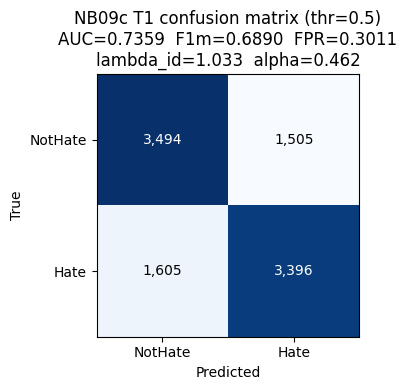

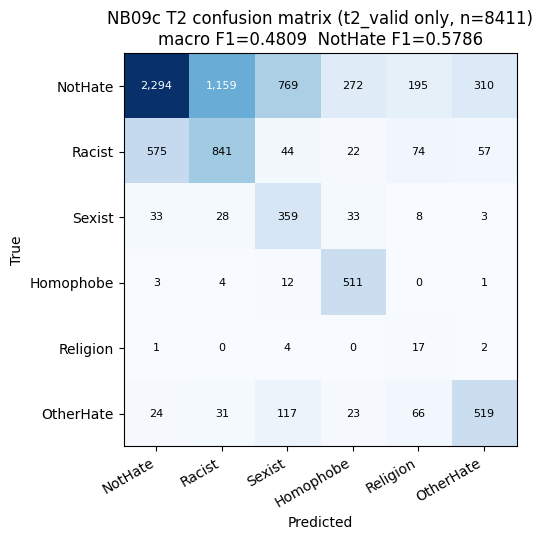

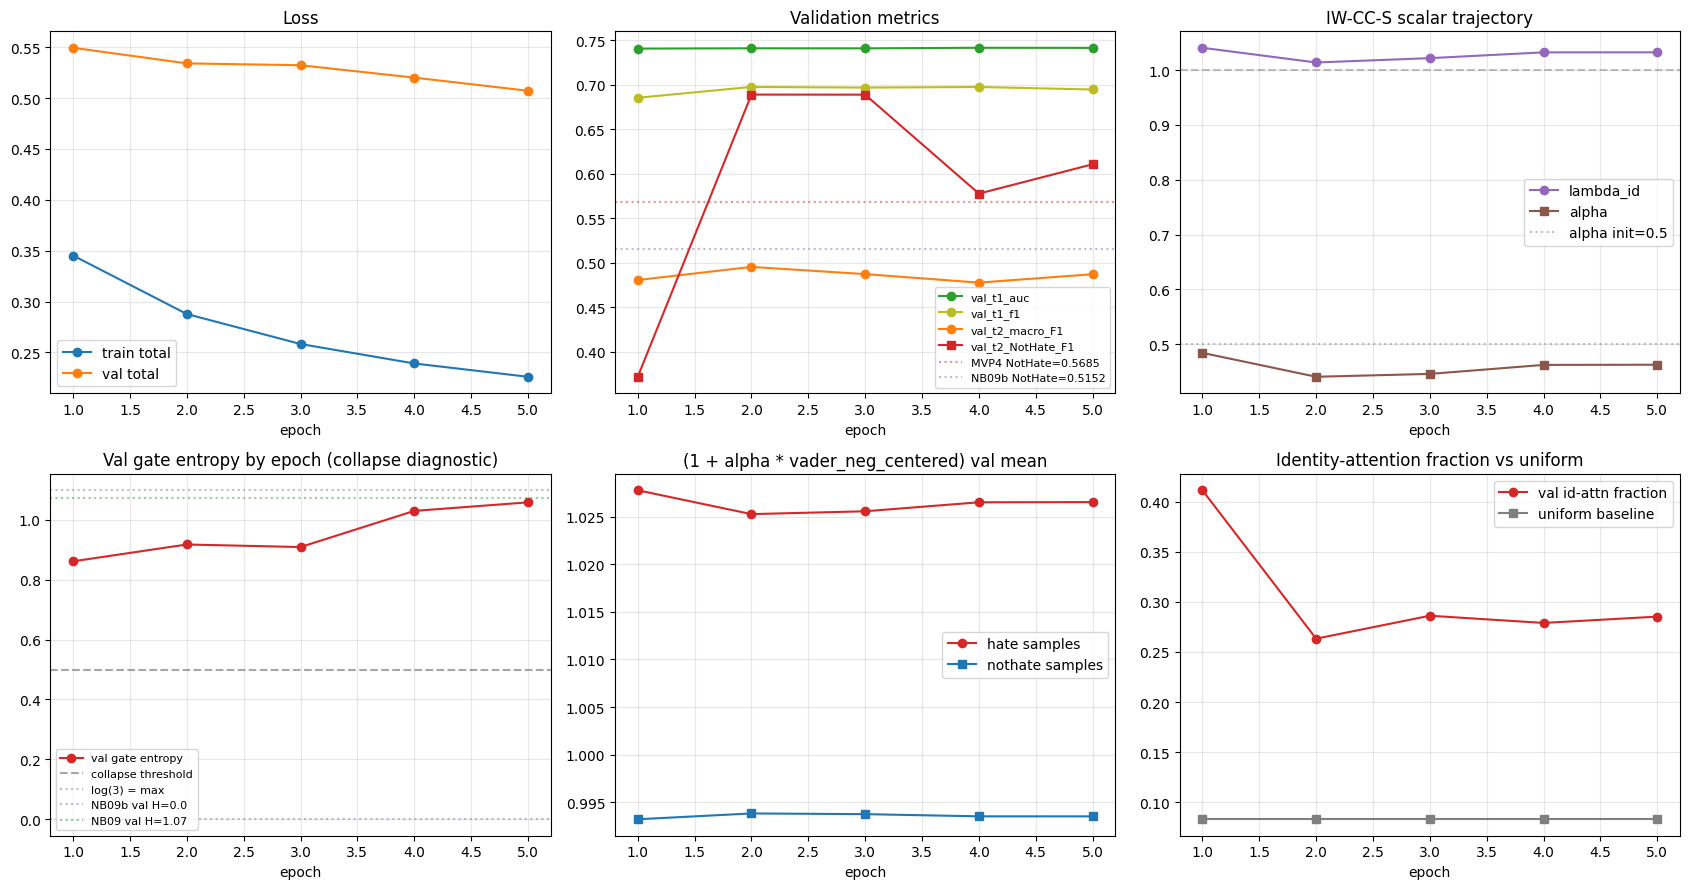

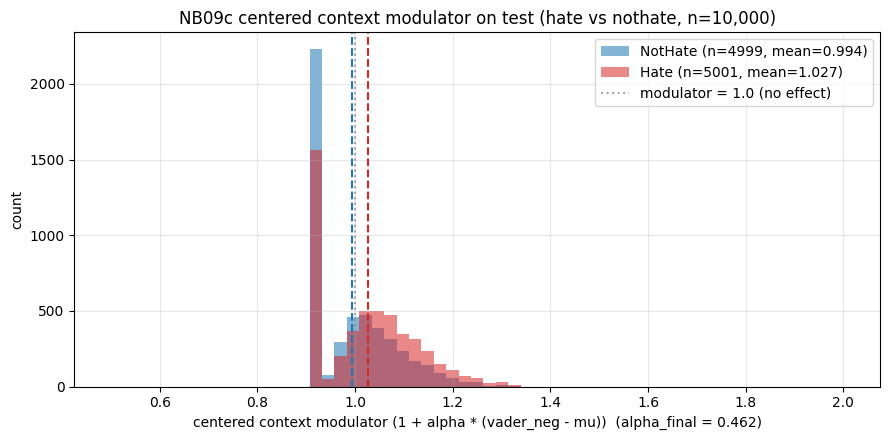

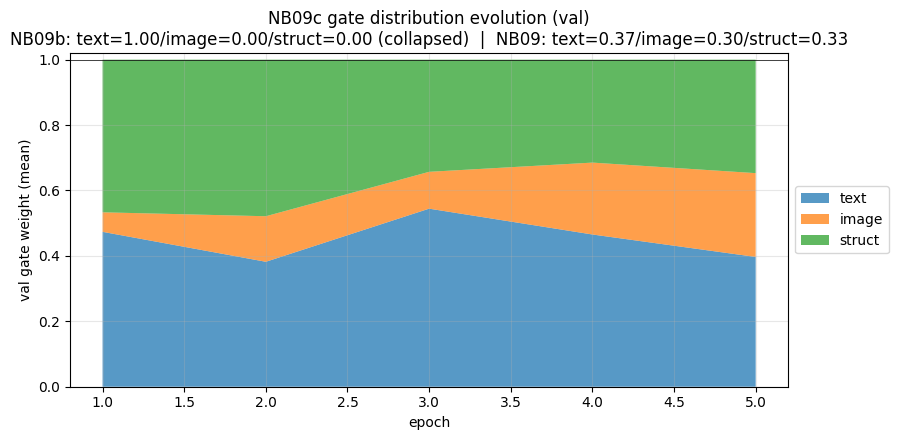

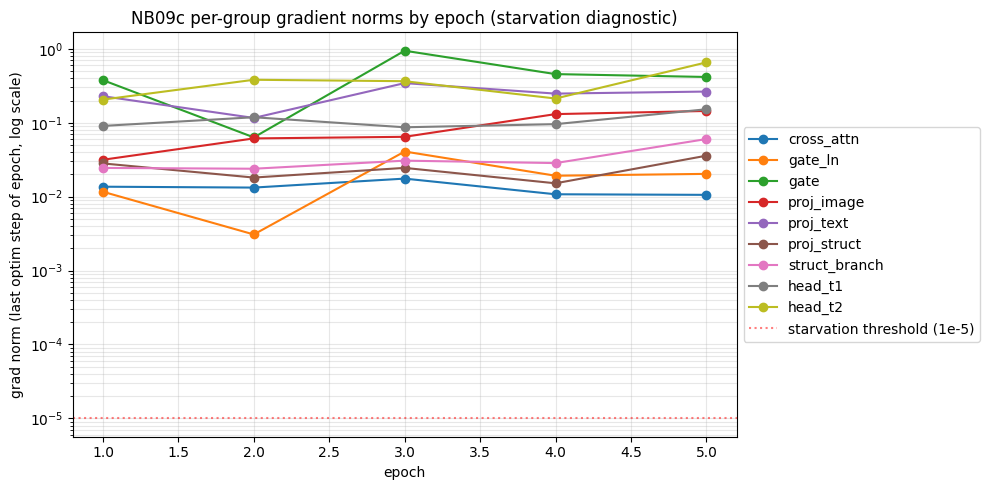

charts saved.


In [14]:
# Cell 15: Load best ckpt, test eval, charts
rest = torch.load(BEST_DIR / 'mvp4_iwccs_trainable.pt', map_location='cpu', weights_only=False)
model.struct_branch.load_state_dict(rest['struct_branch'])
model.cross_attn.load_state_dict(rest['cross_attn'])
model.cross_attn_ln.load_state_dict(rest['cross_attn_ln'])
model.gate_ln_text.load_state_dict(rest['gate_ln_text'])
model.gate_ln_image.load_state_dict(rest['gate_ln_image'])
model.gate_ln_struct.load_state_dict(rest['gate_ln_struct'])
model.gate.load_state_dict(rest['gate'])
model.proj_text.load_state_dict(rest['proj_text'])
model.proj_image.load_state_dict(rest['proj_image'])
model.proj_struct.load_state_dict(rest['proj_struct'])
model.head_t1.load_state_dict(rest['head_t1'])
model.head_t2.load_state_dict(rest['head_t2'])
model.to(device).eval()
lambda_id_final = float(model.cross_attn.lambda_id.detach().item())
alpha_final     = float(model.cross_attn.alpha.detach().item())
print(f'reloaded best (epoch {rest["epoch"]}, val_t1_auc={rest["val_t1_auc"]:.4f}, '
      f'val_t2_macro_f1={rest["val_t2_macro_f1"]:.4f}, val_t2_nothate_f1={rest["val_t2_nothate_f1"]:.4f}, '
      f'val_gate_H={rest["val_gate_H"]:.4f})')
print(f'lambda_id (loaded): {lambda_id_final:.4f}   alpha (loaded): {alpha_final:.4f}')

# Test eval
t1_probs, t1_true = [], []
t2_preds, t2_true, t2_valid_arr = [], [], []
all_gates, tweet_ids_out = [], []
id_attn_fracs, uniform_baselines, ctx_mods = [], [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in test_loader:
        ids  = batch['input_ids'].to(device, non_blocking=True)
        msk  = batch['attention_mask'].to(device, non_blocking=True)
        idm  = batch['identity_mask'].to(device, non_blocking=True)
        pix  = batch['pixel_values'].to(device, non_blocking=True)
        stc  = batch['structured'].to(device, non_blocking=True)
        vnc  = batch['vader_neg_centered'].to(device, non_blocking=True)
        logit_t1, logits_t2, gates, lam_id, alpha_v, attn = model(
            ids, msk, pix, stc, idm, vnc, return_attn=True)
        t1_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
        t1_true.append(batch['t1_label'].cpu().numpy())
        t2_preds.append(logits_t2.argmax(dim=-1).cpu().numpy())
        t2_true.append(batch['t2_label'].cpu().numpy())
        t2_valid_arr.append(batch['t2_valid_mask'].cpu().numpy())
        all_gates.append(gates.float().cpu().numpy())
        tweet_ids_out.append(batch['tweet_id'].cpu().numpy())
        attn_mean = attn.float().mean(dim=1).squeeze(1)
        frac = (attn_mean * idm.float()).sum(dim=-1).cpu().numpy()
        base = (idm.float().sum(dim=-1) / msk.float().sum(dim=-1).clamp(min=1)).cpu().numpy()
        ctx  = (1.0 + alpha_v * vnc.cpu().float()).numpy()
        id_attn_fracs.append(frac); uniform_baselines.append(base); ctx_mods.append(ctx)

all_t1_probs = np.concatenate(t1_probs); all_t1_true = np.concatenate(t1_true)
all_t2_preds = np.concatenate(t2_preds); all_t2_true = np.concatenate(t2_true)
all_t2_valid = np.concatenate(t2_valid_arr); all_gates = np.concatenate(all_gates, axis=0)
all_tweet_ids = np.concatenate(tweet_ids_out)
all_id_attn = np.concatenate(id_attn_fracs)
all_uniform = np.concatenate(uniform_baselines)
all_ctx_mod = np.concatenate(ctx_mods)
print(f'test preds: t1 {all_t1_probs.shape}, gates {all_gates.shape}, id_attn {all_id_attn.shape}')

thr = HPARAMS['threshold']
all_t1_pred = (all_t1_probs >= thr).astype(int)
auc = roc_auc_score(all_t1_true, all_t1_probs)
f1m = f1_score(all_t1_true, all_t1_pred, average='macro')
pm  = precision_score(all_t1_true, all_t1_pred, average='macro', zero_division=0)
rm  = recall_score(all_t1_true, all_t1_pred, average='macro', zero_division=0)
cm  = confusion_matrix(all_t1_true, all_t1_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
fpr = fp / max(fp + tn, 1)
m_bal = {'AUC': float(auc), 'F1m': float(f1m), 'Pm': float(pm), 'Rm': float(rm), 'FPR': float(fpr),
         'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)}
print(f'\n--- T1 BALANCED-TEST metrics (thr={thr}) ---')
for k, v in m_bal.items():
    if isinstance(v, float): print(f'  {k:<5} {v:.4f}')
    else:                    print(f'  {k:<5} {v}')

mask = all_t2_valid.astype(bool)
T2_CLASS_NAMES = ['NotHate', 'Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']
if mask.sum() > 0:
    t2_macro = f1_score(all_t2_true[mask], all_t2_preds[mask], average='macro',
                         labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
    per_class = f1_score(all_t2_true[mask], all_t2_preds[mask], average=None,
                          labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
    cm_t2 = confusion_matrix(all_t2_true[mask], all_t2_preds[mask],
                              labels=list(range(HPARAMS['n_t2_classes'])))
    print(f'\n--- T2 metrics (t2_valid=True only, n={int(mask.sum())}) ---')
    print(f'  macro F1: {t2_macro:.4f}')
    for c, f1c in zip(T2_CLASS_NAMES, per_class):
        marker = '  <-- key diagnostic' if c == 'NotHate' else ''
        print(f'  per-class F1  {c:<10} = {f1c:.4f}{marker}')
    t2_nothate_f1 = float(per_class[0])
else:
    t2_macro = float('nan'); per_class = np.full(HPARAMS['n_t2_classes'], np.nan); cm_t2 = None
    t2_nothate_f1 = float('nan')

# Identity attention split by hate/nothate
hate_mask = (all_t1_true == 1); nothate_mask = (all_t1_true == 0)
id_attn_hate    = float(all_id_attn[hate_mask].mean())    if hate_mask.any()    else float('nan')
id_attn_nothate = float(all_id_attn[nothate_mask].mean()) if nothate_mask.any() else float('nan')
ctx_mod_hate    = float(all_ctx_mod[hate_mask].mean())    if hate_mask.any()    else float('nan')
ctx_mod_nothate = float(all_ctx_mod[nothate_mask].mean()) if nothate_mask.any() else float('nan')

print('\n--- IDENTITY-ATTENTION ANALYSIS (test) ---')
print(f'  lambda_id (final): {lambda_id_final:.4f}   alpha (final): {alpha_final:.4f}')
print(f'  mean id-attention fraction (all):       {all_id_attn.mean():.4f}  (uniform {all_uniform.mean():.4f})')
print(f'    HATE samples (n={int(hate_mask.sum())}):    {id_attn_hate:.4f}')
print(f'    NotHate samples (n={int(nothate_mask.sum())}): {id_attn_nothate:.4f}')
print(f'    delta (hate - nothate):                 {id_attn_hate - id_attn_nothate:+.4f}')
print(f'  mean (1+alpha*vader_neg_centered) modulator:')
print(f'    HATE samples:    {ctx_mod_hate:.4f}')
print(f'    NotHate samples: {ctx_mod_nothate:.4f}')
print(f'    delta:           {ctx_mod_hate - ctx_mod_nothate:+.4f}')

g_mean_test = all_gates.mean(axis=0)
g_std_test  = all_gates.std(axis=0)
gate_H_test = -(all_gates * np.log(all_gates + 1e-8)).sum(axis=-1)
print(f'\n--- TEST gate stats ---')
print(f'  mean: text={g_mean_test[0]:.4f}  image={g_mean_test[1]:.4f}  struct={g_mean_test[2]:.4f}')
print(f'  mean entropy: {gate_H_test.mean():.4f}  (log(3)={float(np.log(3.0)):.4f})')

# Save per-sample artefacts
np.save(MODEL_DIR / 'test_gates.npy',
        np.stack([all_tweet_ids.astype(np.int64),
                  all_gates[:, 0].astype(np.float32),
                  all_gates[:, 1].astype(np.float32),
                  all_gates[:, 2].astype(np.float32)], axis=1))
np.save(MODEL_DIR / 'test_identity_attention.npy',
        np.stack([all_tweet_ids.astype(np.int64),
                  all_id_attn.astype(np.float32),
                  all_uniform.astype(np.float32),
                  all_ctx_mod.astype(np.float32)], axis=1))
print(f'\nsaved test_gates.npy + test_identity_attention.npy to {MODEL_DIR}')

# CHARTS
# T1 confusion matrix
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f'{v:,}', ha='center', va='center', color='black' if v < cm.max()/2 else 'white')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['NotHate', 'Hate']); ax.set_yticklabels(['NotHate', 'Hate'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'NB09c T1 confusion matrix (thr={thr})\nAUC={auc:.4f}  F1m={f1m:.4f}  FPR={fpr:.4f}\nlambda_id={lambda_id_final:.3f}  alpha={alpha_final:.3f}')
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb09c_t1_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# T2 confusion matrix
if cm_t2 is not None:
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.imshow(cm_t2, cmap='Blues')
    for (i, j), v in np.ndenumerate(cm_t2):
        ax.text(j, i, f'{v:,}', ha='center', va='center',
                color='black' if v < cm_t2.max()/2 else 'white', fontsize=8)
    ax.set_xticks(range(HPARAMS['n_t2_classes'])); ax.set_yticks(range(HPARAMS['n_t2_classes']))
    ax.set_xticklabels(T2_CLASS_NAMES, rotation=30, ha='right')
    ax.set_yticklabels(T2_CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'NB09c T2 confusion matrix (t2_valid only, n={int(mask.sum())})\nmacro F1={t2_macro:.4f}  NotHate F1={t2_nothate_f1:.4f}')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'nb09c_t2_confusion_matrix.png', dpi=120, bbox_inches='tight')
    plt.show()

# Training curves: 2x3 panel
hist = history; ep = hist['epoch']
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes[0,0].plot(ep, hist['train_total'], label='train total', marker='o')
axes[0,0].plot(ep, hist['val_total'],   label='val total',   marker='o')
axes[0,0].set_title('Loss'); axes[0,0].set_xlabel('epoch'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ep, hist['val_t1_auc'], label='val_t1_auc',  marker='o', color='tab:green')
axes[0,1].plot(ep, hist['val_t1_f1'],  label='val_t1_f1',   marker='o', color='tab:olive')
axes[0,1].plot(ep, hist['val_t2_macro_f1'],   label='val_t2_macro_F1',   marker='o', color='tab:orange')
axes[0,1].plot(ep, hist['val_t2_nothate_f1'], label='val_t2_NotHate_F1', marker='s', color='tab:red')
axes[0,1].axhline(0.5685, color='tab:red', linestyle=':', alpha=0.5, label='MVP4 NotHate=0.5685')
axes[0,1].axhline(0.5152, color='tab:purple', linestyle=':', alpha=0.5, label='NB09b NotHate=0.5152')
axes[0,1].set_title('Validation metrics'); axes[0,1].set_xlabel('epoch')
axes[0,1].legend(loc='lower right', fontsize=8); axes[0,1].grid(alpha=0.3)

axes[0,2].plot(ep, hist['lambda_id'], marker='o', color='tab:purple', label='lambda_id')
axes[0,2].plot(ep, hist['alpha'],     marker='s', color='tab:brown',  label='alpha')
axes[0,2].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[0,2].axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='alpha init=0.5')
axes[0,2].set_title('IW-CC-S scalar trajectory'); axes[0,2].set_xlabel('epoch')
axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

axes[1,0].plot(ep, hist['val_gate_H'], marker='o', color='tab:red', label='val gate entropy')
axes[1,0].axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='collapse threshold')
axes[1,0].axhline(float(np.log(3)), color='gray', linestyle=':', alpha=0.5, label='log(3) = max')
axes[1,0].axhline(0.0, color='tab:purple', linestyle=':', alpha=0.5, label='NB09b val H=0.0')
axes[1,0].axhline(1.0730, color='tab:green', linestyle=':', alpha=0.5, label='NB09 val H=1.07')
axes[1,0].set_title('Val gate entropy by epoch (collapse diagnostic)'); axes[1,0].set_xlabel('epoch')
axes[1,0].legend(fontsize=8); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ep, hist['val_ctx_mod_mean_hate'],    label='hate samples',    marker='o', color='tab:red')
axes[1,1].plot(ep, hist['val_ctx_mod_mean_nothate'], label='nothate samples', marker='s', color='tab:blue')
axes[1,1].set_title('(1 + alpha * vader_neg_centered) val mean'); axes[1,1].set_xlabel('epoch')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

axes[1,2].plot(ep, hist['val_id_attn_frac_mean'], label='val id-attn fraction', marker='o', color='tab:red')
axes[1,2].plot(ep, hist['val_uniform_baseline_mean'], label='uniform baseline', marker='s', color='tab:gray')
axes[1,2].set_title('Identity-attention fraction vs uniform'); axes[1,2].set_xlabel('epoch')
axes[1,2].legend(); axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'nb09c_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# Context modulation histogram (test set, hate vs non-hate)
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(min(0.5, all_ctx_mod.min()), max(2.0, all_ctx_mod.max()), 60)
ax.hist(all_ctx_mod[nothate_mask], bins=bins, alpha=0.55, color='tab:blue',
        label=f'NotHate (n={int(nothate_mask.sum())}, mean={ctx_mod_nothate:.3f})')
ax.hist(all_ctx_mod[hate_mask],    bins=bins, alpha=0.55, color='tab:red',
        label=f'Hate (n={int(hate_mask.sum())}, mean={ctx_mod_hate:.3f})')
ax.axvline(ctx_mod_nothate, color='tab:blue', linestyle='--')
ax.axvline(ctx_mod_hate,    color='tab:red',  linestyle='--')
ax.axvline(1.0, color='gray', linestyle=':', alpha=0.7, label='modulator = 1.0 (no effect)')
ax.set_xlabel(f'centered context modulator (1 + alpha * (vader_neg - mu))  (alpha_final = {alpha_final:.3f})')
ax.set_ylabel('count')
ax.set_title(f'NB09c centered context modulator on test (hate vs nothate, n={len(all_ctx_mod):,})')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb09c_context_modulation.png', dpi=120, bbox_inches='tight')
plt.show()

# Gate evolution chart — stacked area + NB09b reference line
fig, ax = plt.subplots(figsize=(9, 4.5))
g_t = np.array(hist['val_g_text']); g_i = np.array(hist['val_g_image']); g_s = np.array(hist['val_g_struct'])
ax.stackplot(ep, g_t, g_i, g_s, labels=['text', 'image', 'struct'],
             colors=['tab:blue', 'tab:orange', 'tab:green'], alpha=0.75)
ax.axhline(1.0, color='black', linewidth=0.5)
ax.set_ylim(0, 1.02)
ax.set_xlabel('epoch'); ax.set_ylabel('val gate weight (mean)')
ax.set_title('NB09c gate distribution evolution (val)\nNB09b: text=1.00/image=0.00/struct=0.00 (collapsed)  |  NB09: text=0.37/image=0.30/struct=0.33')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb09c_gate_evolution.png', dpi=120, bbox_inches='tight')
plt.show()

# Per-group grad norms chart
fig, ax = plt.subplots(figsize=(10, 5))
for g in GRAD_GROUP_NAMES:
    vals = np.array(hist[f'grad_norm_{g}'], dtype=np.float64)
    if not np.isnan(vals).all():
        ax.plot(ep, vals, marker='o', label=g)
ax.set_yscale('log')
ax.set_xlabel('epoch'); ax.set_ylabel('grad norm (last optim step of epoch, log scale)')
ax.set_title('NB09c per-group gradient norms by epoch (starvation diagnostic)')
ax.axhline(1e-5, color='red', linestyle=':', alpha=0.5, label='starvation threshold (1e-5)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5)); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb09c_grad_norms.png', dpi=120, bbox_inches='tight')
plt.show()

print('charts saved.')

In [15]:
# Cell 16: Recalibrated metrics (Bayes shift to 22% hate prior)
prior_hate    = HPARAMS['prior_hate']
prior_nothate = HPARAMS['prior_nothate']

def recalibrate(p, ph=prior_hate, pn=prior_nothate):
    num = p * ph
    den = num + (1 - p) * pn
    return num / np.maximum(den, 1e-12)

v_probs, v_true = [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in val_loader:
        ids = batch['input_ids'].to(device, non_blocking=True)
        msk = batch['attention_mask'].to(device, non_blocking=True)
        idm = batch['identity_mask'].to(device, non_blocking=True)
        pix = batch['pixel_values'].to(device, non_blocking=True)
        stc = batch['structured'].to(device, non_blocking=True)
        vnc = batch['vader_neg_centered'].to(device, non_blocking=True)
        logit_t1, _, _, _, _ = model(ids, msk, pix, stc, idm, vnc)
        v_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
        v_true.append(batch['t1_label'].cpu().numpy())
val_probs_arr = np.concatenate(v_probs); val_true_arr = np.concatenate(v_true)

test_probs_recal = recalibrate(all_t1_probs)
val_probs_recal  = recalibrate(val_probs_arr)

best_thr, best_thr_f1 = 0.5, -1.0
for t in np.linspace(0.01, 0.99, 99):
    pred = (val_probs_recal >= t).astype(int)
    fv = f1_score(val_true_arr, pred)
    if fv > best_thr_f1:
        best_thr_f1 = fv; best_thr = float(t)
print(f'F1-opt threshold on RECALIBRATED VAL: {best_thr:.3f} (val F1={best_thr_f1:.4f})')

pred_recal = (test_probs_recal >= best_thr).astype(int)
auc_r = roc_auc_score(all_t1_true, test_probs_recal)
f1m_r = f1_score(all_t1_true, pred_recal, average='macro')
pm_r  = precision_score(all_t1_true, pred_recal, average='macro', zero_division=0)
rm_r  = recall_score(all_t1_true, pred_recal, average='macro', zero_division=0)
cm_r  = confusion_matrix(all_t1_true, pred_recal, labels=[0, 1])
tn_r, fp_r, fn_r, tp_r = cm_r.ravel()
fpr_r = fp_r / max(fp_r + tn_r, 1)
m_rec = {'AUC': float(auc_r), 'F1m': float(f1m_r), 'Pm': float(pm_r), 'Rm': float(rm_r), 'FPR': float(fpr_r),
         'TN': int(tn_r), 'FP': int(fp_r), 'FN': int(fn_r), 'TP': int(tp_r), 'threshold': float(best_thr)}

print('\n--- BALANCED-TEST  vs  RECALIBRATED-TEST  T1 metrics ---')
print(f'  {"":<7} {"balanced (thr=0.5)":>22} {"recalibrated (thr opt)":>24}')
for k in ['AUC', 'F1m', 'Pm', 'Rm', 'FPR']:
    print(f'  {k:<7} {m_bal[k]:>22.4f} {m_rec[k]:>24.4f}')
print(f'  CM bal: TN={m_bal["TN"]} FP={m_bal["FP"]} FN={m_bal["FN"]} TP={m_bal["TP"]}')
print(f'  CM rec: TN={m_rec["TN"]} FP={m_rec["FP"]} FN={m_rec["FN"]} TP={m_rec["TP"]} (thr={best_thr:.3f})')

F1-opt threshold on RECALIBRATED VAL: 0.220 (val F1=0.7037)

--- BALANCED-TEST  vs  RECALIBRATED-TEST  T1 metrics ---
              balanced (thr=0.5)   recalibrated (thr opt)
  AUC                     0.7359                   0.7359
  F1m                     0.6890                   0.6808
  Pm                      0.6891                   0.6833
  Rm                      0.6890                   0.6816
  FPR                     0.3011                   0.3671
  CM bal: TN=3494 FP=1505 FN=1605 TP=3396
  CM rec: TN=3164 FP=1835 FN=1349 TP=3652 (thr=0.220)


In [16]:
# Cell 17: 7-row comparison + 5 success criteria + verdict + save

def load_gate_means(path):
    p = Path(path)
    if not p.exists(): return None
    g = np.load(p)
    return {'text': float(g[:,1].mean()), 'image': float(g[:,2].mean()), 'struct': float(g[:,3].mean()),
            'H': float((-(g[:,1:4] * np.log(g[:,1:4]+1e-8)).sum(axis=1)).mean())}

mvp4_gate   = load_gate_means(ROOT / 'models/mvp4_gated_fusion/test_gates.npy')
mvp4iw_gate = load_gate_means(ROOT / 'models/mvp4_iw_attention/test_gates.npy')
mvp4cc_gate = load_gate_means(ROOT / 'models/mvp4_iwcc_attention/test_gates.npy')
this_gate   = {'text': float(g_mean_test[0]), 'image': float(g_mean_test[1]), 'struct': float(g_mean_test[2]),
               'H':    float(gate_H_test.mean())}

mvp1   = {'AUC': 0.7431, 'F1m': 0.6855, 'FPR': 0.2667, 'T2': None,   'T2_NotHate': None,   'gate': None, 'label': 'MVP 1 (text only)'}
mvp2   = {'AUC': 0.7411, 'F1m': 0.6892, 'FPR': 0.3041, 'T2': 0.3795, 'T2_NotHate': None,   'gate': None, 'label': 'MVP 2 (T+I naive)'}
mvp3   = {'AUC': 0.7406, 'F1m': 0.6905, 'FPR': 0.3361, 'T2': 0.4787, 'T2_NotHate': None,   'gate': None, 'label': 'MVP 3 (T+I+S naive)'}
mvp4   = {'AUC': 0.7400, 'F1m': 0.6888, 'FPR': 0.3071, 'T2': 0.4933, 'T2_NotHate': 0.5685, 'gate': mvp4_gate,   'label': 'MVP 4 (gated)'}
mvp4iw = {'AUC': 0.7359, 'F1m': 0.6876, 'FPR': 0.2857, 'T2': 0.4308, 'T2_NotHate': 0.3378, 'gate': mvp4iw_gate, 'label': 'MVP 4-IW (NB09)'}
mvp4cc = {'AUC': 0.7340, 'F1m': 0.6882, 'FPR': 0.2981, 'T2': 0.4687, 'T2_NotHate': 0.5152, 'gate': mvp4cc_gate, 'label': 'MVP 4-IW-CC (NB09b)'}
this   = {'AUC': m_bal['AUC'], 'F1m': m_bal['F1m'], 'FPR': m_bal['FPR'],
          'T2': float(t2_macro) if not (isinstance(t2_macro, float) and math.isnan(t2_macro)) else None,
          'T2_NotHate': t2_nothate_f1, 'gate': this_gate, 'label': 'MVP 4-IW-CC-S (this)'}

def fmt(v):
    return f'{v:.4f}' if isinstance(v, (int, float)) and v is not None else 'n/a'
def gfmt(g):
    return 'n/a' if g is None else f'{g["text"]:.2f}/{g["image"]:.2f}/{g["struct"]:.2f}  H={g["H"]:.2f}'

rows = [mvp1, mvp2, mvp3, mvp4, mvp4iw, mvp4cc, this]
print('=' * 110)
print('7-row comparison (balanced 50/50 test, thr=0.5)')
print('=' * 110)
print(f'  {"":<24} {"AUC":>8} {"F1m":>8} {"FPR":>8} {"T2":>8} {"T2_NH":>8}  {"Gate (t/i/s + H)":<28}')
for r in rows:
    print(f'  {r["label"]:<24} {fmt(r["AUC"]):>8} {fmt(r["F1m"]):>8} {fmt(r["FPR"]):>8} {fmt(r["T2"]):>8} {fmt(r["T2_NotHate"]):>8}  {gfmt(r["gate"]):<28}')

def delta(a, b): return None if (a is None or b is None) else a - b
def dfmt(d): return 'n/a' if d is None else f'{d:+.4f}'

print('\nDeltas vs MVP 4-IW-CC (NB09b — primary collapse-fix comparison):')
for k in ['AUC', 'F1m', 'FPR', 'T2', 'T2_NotHate']:
    print(f'  d_{k:<10} = {dfmt(delta(this[k], mvp4cc[k]))}')
print('\nDeltas vs MVP 4-IW (NB09):')
for k in ['AUC', 'F1m', 'FPR', 'T2', 'T2_NotHate']:
    print(f'  d_{k:<10} = {dfmt(delta(this[k], mvp4iw[k]))}')
print('\nDeltas vs MVP 4 (NB08, original baseline):')
for k in ['AUC', 'F1m', 'FPR', 'T2', 'T2_NotHate']:
    print(f'  d_{k:<10} = {dfmt(delta(this[k], mvp4[k]))}')

# FIVE success criteria
final_test_gate_H = float(gate_H_test.mean())
epoch1_val_gate_H = float(history['val_gate_H'][0]) if history['val_gate_H'] else float('nan')

crit_a  = final_test_gate_H > 0.5
crit_a2 = epoch1_val_gate_H > 0.5
crit_b  = (this['T2_NotHate'] is not None) and (this['T2_NotHate'] >= 0.45)
crit_c  = this['FPR'] <= 0.32
crit_d  = alpha_final > 0.1

print('\n' + '=' * 78)
print('FIVE SUCCESS CRITERIA')
print('=' * 78)
print(f'  (a)  Final test gate entropy > 0.5:       H={final_test_gate_H:.4f}                  -> {"PASS" if crit_a else "FAIL"}')
print(f'  (a\') Epoch-1 val gate entropy > 0.5:      H={epoch1_val_gate_H:.4f}                  -> {"PASS" if crit_a2 else "FAIL"}')
print(f'  (b)  T2 NotHate F1 >= 0.45:               {fmt(this["T2_NotHate"])}                  -> {"PASS" if crit_b else "FAIL"}')
print(f'  (c)  FPR <= 0.32:                         {fmt(this["FPR"])}                  -> {"PASS" if crit_c else "FAIL"}')
print(f'  (d)  alpha > 0.1 at convergence:          alpha_final={alpha_final:.4f}        -> {"PASS" if crit_d else "FAIL"}')
n_pass = sum([crit_a, crit_a2, crit_b, crit_c, crit_d])
print(f'\n  PASS COUNT: {n_pass}/5')

# Per-group grad norm summary across epochs (find which arm dominated / starved)
print('\nPer-group grad norms (final epoch):')
final_grad = {g: history[f'grad_norm_{g}'][-1] for g in GRAD_GROUP_NAMES if history[f'grad_norm_{g}']}
sorted_grad = sorted(final_grad.items(), key=lambda x: x[1] if x[1] == x[1] else 0, reverse=True)
for g, v in sorted_grad:
    print(f'  {g:<14} = {v:.6e}')

# Honest verdict
verdict_lines = []
gate_recovered = crit_a and crit_a2
nothate_kept = crit_b
fpr_kept = crit_c
alpha_active = crit_d
if n_pass == 5:
    verdict_lines.append('STRONG WIN: all five criteria pass.')
    verdict_lines.append('  + Gate did NOT collapse (both final and epoch-1 thresholds passed).')
    verdict_lines.append(f'  + NotHate F1 = {this["T2_NotHate"]:.4f} (kept above 0.45 target).')
    verdict_lines.append(f'  + FPR = {this["FPR"]:.4f} (within 0.32 ceiling).')
    verdict_lines.append(f'  + alpha_final = {alpha_final:.4f} (mechanism remained active).')
    verdict_lines.append('  -> Centering + per-branch LN + lower alpha init prevented the NB09b collapse.')
elif gate_recovered and not nothate_kept:
    verdict_lines.append('GATE RECOVERED but NotHate slipped — partial win.')
elif not gate_recovered:
    verdict_lines.append('GATE STILL COLLAPSED — H1+H2 fixes were NOT sufficient.')
    verdict_lines.append(f'  Final test gate H = {final_test_gate_H:.4f}, epoch-1 val H = {epoch1_val_gate_H:.4f}.')
    verdict_lines.append('  Recommendation: proceed to NB09d with entropy_weight=0.10 as a separate single-variable change.')
else:
    verdict_lines.append(f'MIXED OUTCOME ({n_pass}/5 criteria passed). See per-criterion table above.')

# Identify which architectural fix carried weight (read off grad norms)
gate_ln_norm  = history['grad_norm_gate_ln'][-1]    if history['grad_norm_gate_ln']    else float('nan')
cross_atn_norm= history['grad_norm_cross_attn'][-1] if history['grad_norm_cross_attn'] else float('nan')
proj_img_norm = history['grad_norm_proj_image'][-1] if history['grad_norm_proj_image'] else float('nan')
verdict_lines.append('')
verdict_lines.append('Which arm is doing the work (final-epoch grad norms):')
verdict_lines.append(f'  gate_ln    = {gate_ln_norm:.4e}   {"(active)"      if gate_ln_norm > 1e-5    else "(starved)"}')
verdict_lines.append(f'  cross_attn = {cross_atn_norm:.4e}   {"(active)"      if cross_atn_norm > 1e-5 else "(starved)"}')
verdict_lines.append(f'  proj_image = {proj_img_norm:.4e}   {"(active)"      if proj_img_norm > 1e-5  else "(starved — image-path dead)"}')

verdict = '\n  '.join(verdict_lines)
print('\n' + '=' * 78)
print('HONEST VERDICT')
print('=' * 78)
print('  ' + verdict)

# Save final artefacts
shutil.copy(BEST_DIR / 'mvp4_iwccs_trainable.pt', MODEL_DIR / 'mvp4_iwccs_trainable.pt')
shutil.copy(BEST_DIR / 'standardisation_stats.json', MODEL_DIR / 'standardisation_stats.json')

with open(MODEL_DIR / 'hparams.json', 'w') as f:
    json.dump({k: v for k, v in HPARAMS.items()}, f, indent=2)
with open(MODEL_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

metrics_payload = {
    'run_label': 'mvp4_iwccs_attention',
    'best_epoch': int(best_epoch),
    'best_val_t1_auc': float(best_t1_auc),
    'best_val_t2_macro_f1':   float(history['val_t2_macro_f1'][best_epoch - 1])   if best_epoch >= 1 else None,
    'best_val_t2_nothate_f1': float(history['val_t2_nothate_f1'][best_epoch - 1]) if best_epoch >= 1 else None,
    't1_pos_weight': float(pos_weight_value),
    't1_thresholds': {'balanced_headline': 0.5, 'recal_f1_optimised_on_recal_val': float(best_thr)},
    'priors_for_recalibration': {'hate': prior_hate, 'nothate': prior_nothate},
    't1_balanced_test_thr_0.5':       m_bal,
    't1_recalibrated_test_thr_opt':   m_rec,
    't2_test_macro_f1_valid_only':    float(t2_macro),
    't2_test_nothate_f1':             float(t2_nothate_f1),
    't2_test_per_class_f1':           {c: float(v) for c, v in zip(T2_CLASS_NAMES, per_class)},
    't2_test_n_valid':                int(mask.sum()),
    'loss_weights': {'t1': HPARAMS['t1_weight'], 't2': HPARAMS['t2_weight'], 'entropy': HPARAMS['entropy_weight']},
    'iwccs_specific': {
        'lambda_id_init':  float(HPARAMS['lambda_id_init']),
        'lambda_id_final': lambda_id_final,
        'alpha_init':      float(HPARAMS['alpha_init']),
        'alpha_final':     alpha_final,
        'mu_vneg_train':   mu_vneg_train,
        'mean_identity_attention_fraction_test':         float(all_id_attn.mean()),
        'mean_identity_attention_fraction_test_hate':    id_attn_hate,
        'mean_identity_attention_fraction_test_nothate': id_attn_nothate,
        'mean_uniform_baseline_test':                    float(all_uniform.mean()),
        'mean_ctx_modulator_test_hate':                  ctx_mod_hate,
        'mean_ctx_modulator_test_nothate':               ctx_mod_nothate,
    },
    'gate_distribution_test': this_gate,
    'comparison': {
        'mvp1': mvp1, 'mvp2': mvp2, 'mvp3': mvp3, 'mvp4': mvp4,
        'mvp4_iw': mvp4iw, 'mvp4_iwcc': mvp4cc, 'mvp4_iwccs': this,
        'delta_vs_mvp4_iwcc':    {k: delta(this[k], mvp4cc[k])   for k in ['AUC','F1m','FPR','T2','T2_NotHate']},
        'delta_vs_mvp4_iw':      {k: delta(this[k], mvp4iw[k])   for k in ['AUC','F1m','FPR','T2','T2_NotHate']},
        'delta_vs_mvp4':         {k: delta(this[k], mvp4[k])     for k in ['AUC','F1m','FPR','T2','T2_NotHate']},
        'criterion_a_final_gate_H_gt_05':   bool(crit_a),
        'criterion_a_prime_epoch1_gate_H_gt_05': bool(crit_a2),
        'criterion_b_nothate_f1_geq_045':   bool(crit_b),
        'criterion_c_fpr_leq_032':          bool(crit_c),
        'criterion_d_alpha_meaningful':     bool(crit_d),
        'n_success_axes_passed':            int(n_pass),
        'verdict':                          verdict,
    },
}
with open(MODEL_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_payload, f, indent=2)

with open(MODEL_DIR / 'iwccs_stats.json', 'w') as f:
    json.dump({
        'lambda_id_final': lambda_id_final,
        'alpha_init':      float(HPARAMS['alpha_init']),
        'alpha_final':     alpha_final,
        'mu_vneg_train':   mu_vneg_train,
        'gate_mean':  {'text': float(g_mean_test[0]), 'image': float(g_mean_test[1]), 'struct': float(g_mean_test[2])},
        'gate_std':   {'text': float(g_std_test[0]),  'image': float(g_std_test[1]),  'struct': float(g_std_test[2])},
        'mean_gate_entropy_test': float(gate_H_test.mean()),
        'epoch1_val_gate_entropy': epoch1_val_gate_H,
        'mean_id_attention_fraction_test': float(all_id_attn.mean()),
        'mean_id_attention_fraction_test_hate':    id_attn_hate,
        'mean_id_attention_fraction_test_nothate': id_attn_nothate,
        'mean_uniform_baseline_test':      float(all_uniform.mean()),
        'mean_ctx_modulator_test_hate':    ctx_mod_hate,
        'mean_ctx_modulator_test_nothate': ctx_mod_nothate,
        'n_test': int(len(all_id_attn)),
    }, f, indent=2)

with open(MODEL_DIR / 'grad_norms_history.json', 'w') as f:
    json.dump({g: history[f'grad_norm_{g}'] for g in GRAD_GROUP_NAMES}, f, indent=2)

print(f'\nartifacts saved to {MODEL_DIR}:')
for p in sorted(MODEL_DIR.iterdir()):
    sz_kb = p.stat().st_size / 1024
    print(f'  {p.name:<35} {sz_kb:>10.1f} KB')
print(f'best checkpoint:        {BEST_DIR / "mvp4_iwccs_trainable.pt"}')
print('\nDONE.')

7-row comparison (balanced 50/50 test, thr=0.5)
                                AUC      F1m      FPR       T2    T2_NH  Gate (t/i/s + H)            
  MVP 1 (text only)          0.7431   0.6855   0.2667      n/a      n/a  n/a                         
  MVP 2 (T+I naive)          0.7411   0.6892   0.3041   0.3795      n/a  n/a                         
  MVP 3 (T+I+S naive)        0.7406   0.6905   0.3361   0.4787      n/a  n/a                         
  MVP 4 (gated)              0.7400   0.6888   0.3071   0.4933   0.5685  0.44/0.24/0.32  H=1.05      
  MVP 4-IW (NB09)            0.7359   0.6876   0.2857   0.4308   0.3378  0.37/0.30/0.33  H=1.07      
  MVP 4-IW-CC (NB09b)        0.7340   0.6882   0.2981   0.4687   0.5152  1.00/0.00/0.00  H=0.00      
  MVP 4-IW-CC-S (this)       0.7359   0.6890   0.3011   0.4809   0.5786  0.47/0.22/0.31  H=1.03      

Deltas vs MVP 4-IW-CC (NB09b — primary collapse-fix comparison):
  d_AUC        = +0.0019
  d_F1m        = +0.0008
  d_FPR        = +0.